# Final Report Project 2

## Task A. An overview of the dataset

In [1]:
import numpy as np
import pandas as pd
import pickle
import missingno as msno
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter
import nltk
nltk.download("stopwords", quiet=True)
from nltk.corpus import stopwords
stopwords_english = stopwords.words("english")
from scipy.stats import chi2_contingency
from scipy import stats
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Guest\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

**1.Load the data as a pandas DataFrame**

In [2]:
df = pd.read_pickle("data_385k.pkl", compression='zip')

**2. Checking the number of rows and columns.** 

In [3]:
rows_num, column_num = df.shape
print(f"number of rows: {rows_num} and number of columns: {column_num}")

number of rows: 385384 and number of columns: 99


**3. A few entries from the DataFrame.**

In [4]:
df.head()

,alcohol_by_volume,barcode,calcium_per_hundred,calcium_unit,carbohydrates_per_hundred,carbohydrates_per_portion,carbohydrates_unit,cholesterol_per_hundred,cholesterol_unit,copper_cu_per_hundred,...,vitamin_b5_panthothenic_acid_per_hundred,vitamin_b5_panthothenic_acid_unit,vitamin_b6_pyridoxin_per_hundred,vitamin_b6_pyridoxin_unit,vitamin_c_ascorbic_acid_per_hundred,vitamin_c_ascorbic_acid_unit,vitamin_d_d2_d3_international_units_per_hundred,vitamin_d_d2_d3_international_units_unit,zinc_per_hundred,zinc_unit
0,0.0,8001772000030,NaN,NaN,75.00,37.50,g,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.0,7610809001066,NaN,NaN,1.50,1.13,g,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.0,8002530159021,NaN,NaN,52.68,NaN,g,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.0,3033715065788,NaN,NaN,70.40,11.97,g,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.0,7610848492740,NaN,NaN,37.00,7.40,g,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**4. Data type for each column.**

Creating a sperate list of similar datatype columns.


In [5]:
column_types = {
    'int64': df.select_dtypes('int64').columns.tolist(),
    'float64': df.select_dtypes('float64').columns.tolist(),
    'object': df.select_dtypes('object').columns.tolist()
}

print("column_types['int64']:", column_types['int64'])
print("column_types['float64']:", column_types['float64'])
print("column_types['object']:", column_types['object'])

column_types['int64']: ['id']
column_types['float64']: ['alcohol_by_volume', 'calcium_per_hundred', 'carbohydrates_per_hundred', 'carbohydrates_per_portion', 'cholesterol_per_hundred', 'copper_cu_per_hundred', 'energy_kcal_per_hundred', 'energy_kcal_per_portion', 'energy_per_hundred', 'energy_per_portion', 'fat_per_hundred', 'fat_per_portion', 'fatty_acids_total_saturated_per_hundred', 'fatty_acids_total_trans_per_hundred', 'fiber_insoluble_per_hundred', 'fiber_per_hundred', 'fiber_per_portion', 'fiber_soluble_per_hundred', 'folate_total_per_hundred', 'folic_acid_per_hundred', 'iron_per_hundred', 'magnesium_per_hundred', 'manganese_mn_per_hundred', 'monounsaturated_fatty_acids_per_hundred', 'phosphorus_per_hundred', 'polyunsaturated_fatty_acids_per_hundred', 'portion_quantity', 'potassium_k_per_hundred', 'protein_per_hundred', 'protein_per_portion', 'quantity', 'salt_per_hundred', 'salt_per_portion', 'saturated_fat_per_hundred', 'saturated_fat_per_portion', 'sodium_per_hundred', 'sodiu

**5. Checking the data by the type of information they hold.**

Creating 3 lists that hold the columns ending in _per_hundred, _per_portion and _unit, respectively and rest of the columns I am putting in other_cols list.

In [6]:
per_hundred_cols = [col for col in df.columns if col.endswith('_per_hundred')]
per_portion_cols = [col for col in df.columns if col.endswith('_per_portion')]
unit_cols = [col for col in df.columns if col.endswith('_unit')]
other_cols = [col for col in df.columns if not col.endswith(('_unit', '_per_portion', '_per_hundred'))]

print("Columns ending with '_per_hundred':", per_hundred_cols)
print("Columns ending with '_per_portion':", per_portion_cols)
print("Columns ending with '_unit':", unit_cols)
print("Other columns:", other_cols)

Columns ending with '_per_hundred': ['calcium_per_hundred', 'carbohydrates_per_hundred', 'cholesterol_per_hundred', 'copper_cu_per_hundred', 'energy_kcal_per_hundred', 'energy_per_hundred', 'fat_per_hundred', 'fatty_acids_total_saturated_per_hundred', 'fatty_acids_total_trans_per_hundred', 'fiber_insoluble_per_hundred', 'fiber_per_hundred', 'fiber_soluble_per_hundred', 'folate_total_per_hundred', 'folic_acid_per_hundred', 'iron_per_hundred', 'magnesium_per_hundred', 'manganese_mn_per_hundred', 'monounsaturated_fatty_acids_per_hundred', 'phosphorus_per_hundred', 'polyunsaturated_fatty_acids_per_hundred', 'potassium_k_per_hundred', 'protein_per_hundred', 'salt_per_hundred', 'saturated_fat_per_hundred', 'sodium_per_hundred', 'sugars_added_per_hundred', 'sugars_per_hundred', 'vitamin_a_iu_per_hundred', 'vitamin_b12_cobalamin_per_hundred', 'vitamin_b1_thiamin_per_hundred', 'vitamin_b2_riboflavin_per_hundred', 'vitamin_b3_niacin_per_hundred', 'vitamin_b5_panthothenic_acid_per_hundred', 'vita

## Task B. Data Cleaning

**1. Now, checking Is there any duplicate rows in the data?**

In [7]:
df.duplicated().sum()
print("Number of duplicated rows in the data:", df.duplicated().sum())

Number of duplicated rows in the data: 10500


We found some duplicate rows so now removing them and checking data after that.

In [8]:
shape_original = df.shape
df_remove_duplicates = df.drop_duplicates()
shape_after_removal = df_remove_duplicates.shape
print(f"Original shape: {shape_original} and shape after removing duplicates: {shape_after_removal}")


Original shape: (385384, 99) and shape after removing duplicates: (374884, 99)


**2. Checking missing values if any**

2 a). Creating a table that shows both the number and the percentage of missing values for all columns and then sorted them from largest to smallest.

In [9]:
missing_value_count = df_remove_duplicates.isnull().sum()
missing_percentage = (df_remove_duplicates.isnull().sum() / len(df_remove_duplicates)) * 100
missing_data = pd.concat([missing_value_count, missing_percentage], axis=1)
missing_data.columns = ['missing_value','missing_percentage' ]
missing_data_sorted = missing_data.sort_values(by='missing_value', ascending=False)
print(missing_data_sorted.to_markdown())

|                                                 |   missing_value |   missing_percentage |
|:------------------------------------------------|----------------:|---------------------:|
| sodium_per_portion                              |          374131 |             99.7991  |
| fiber_insoluble_per_hundred                     |          371375 |             99.064   |
| fiber_insoluble_unit                            |          371374 |             99.0637  |
| manganese_mn_per_hundred                        |          371350 |             99.0573  |
| manganese_mn_unit                               |          371347 |             99.0565  |
| copper_cu_per_hundred                           |          371273 |             99.0368  |
| copper_cu_unit                                  |          371273 |             99.0368  |
| fiber_soluble_per_hundred                       |          371057 |             98.9792  |
| fiber_soluble_unit                              |          371055 | 

2 b). We can visualize the missing values in the whole data frame using _missingo_.

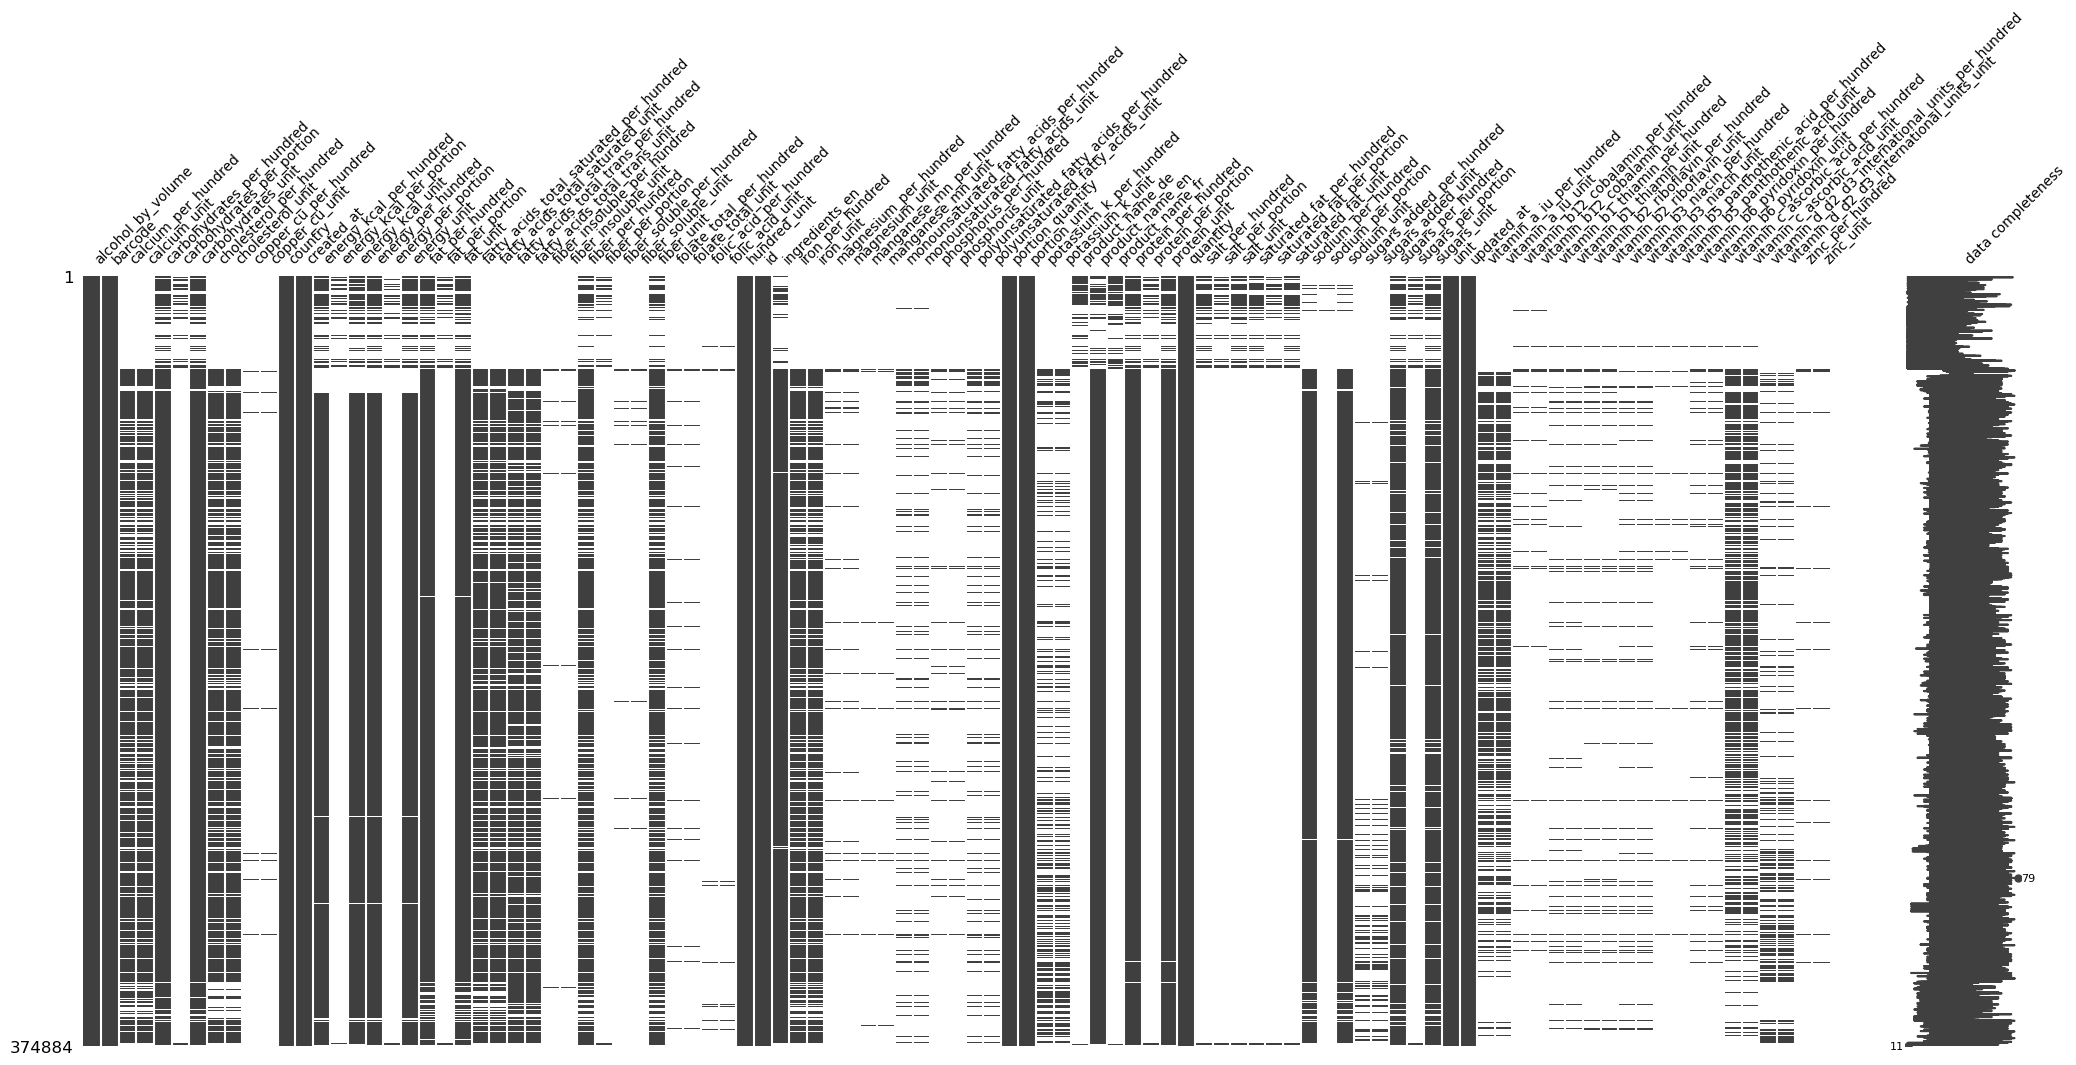

In [10]:
msno.matrix(df_remove_duplicates, labels=True, label_rotation=45, fontsize=10, figsize=(25, 10))
plt.show()

2 c). Plot charts that show the percentages of missing values in each list.

Here, Plotting chart that show the percentages of missing values in _per_hundred_cols_.

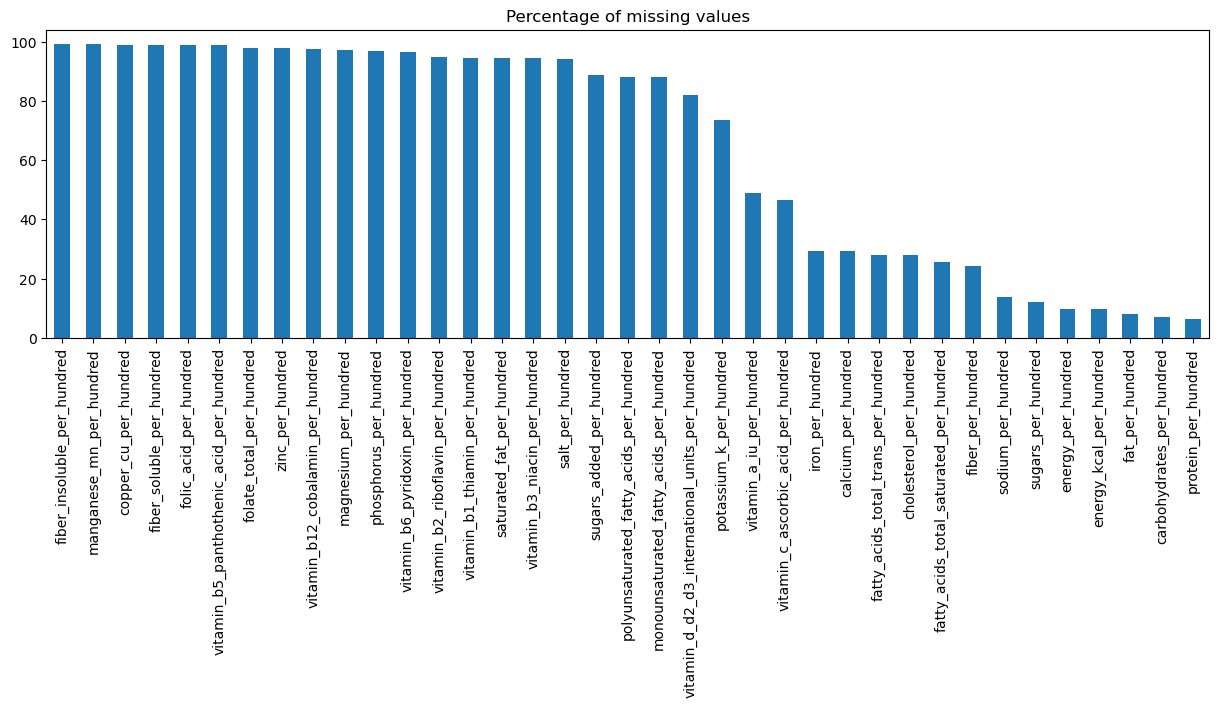

In [11]:
missing_percentage[per_hundred_cols].sort_values(ascending=False).plot(kind="bar", figsize=(15, 4), title="Percentage of missing values")
plt.show()

Plotting chart that show the percentages of missing values in _per_portion_cols_.

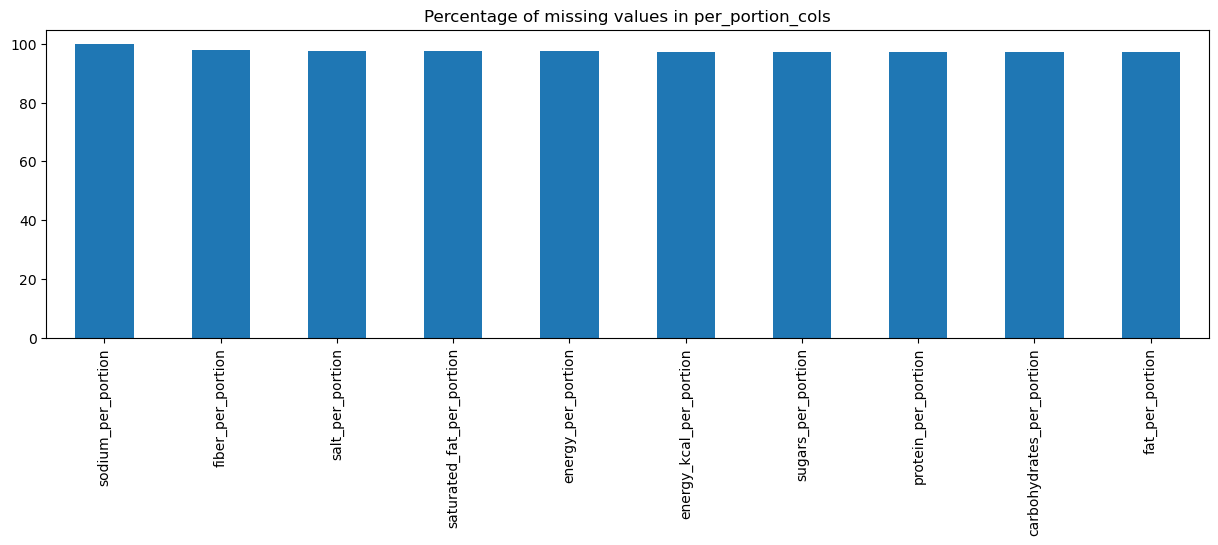

In [12]:
missing_percentage[per_portion_cols].sort_values(ascending=False).plot(kind="bar", figsize=(15, 4), title="Percentage of missing values in per_portion_cols")
plt.show()

Plotting chart that show the percentages of missing values in _unit_cols_.

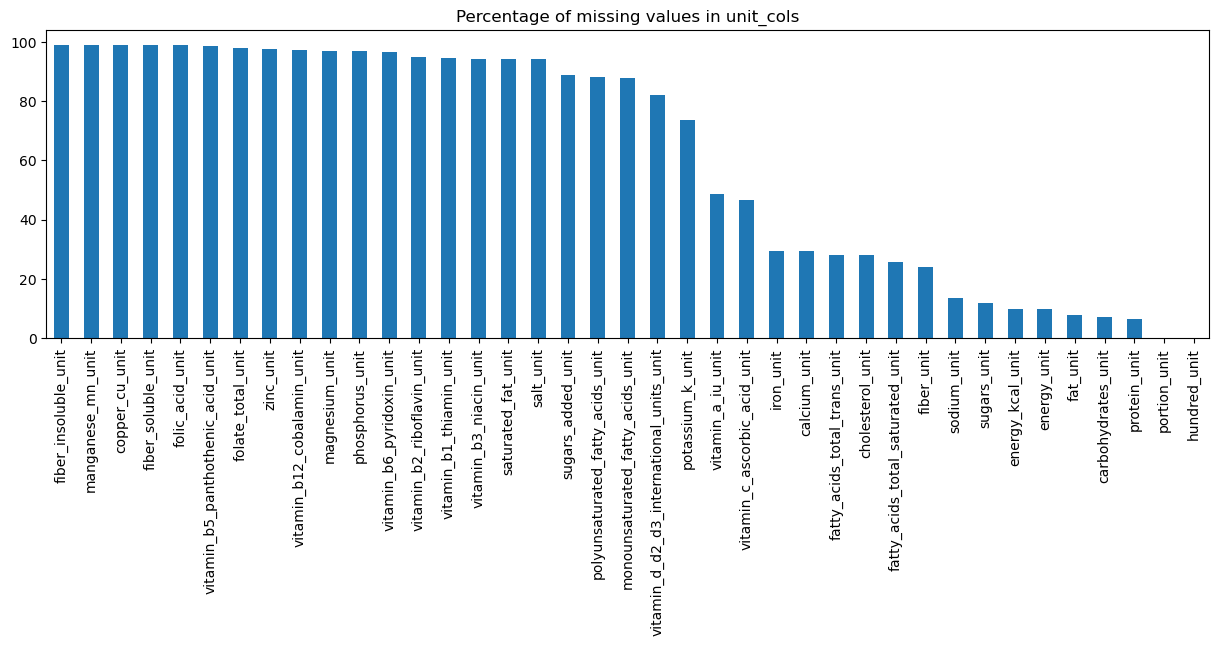

In [13]:
missing_percentage[unit_cols].sort_values(ascending=False).plot(kind="bar", figsize=(15, 4), title="Percentage of missing values in unit_cols")
plt.show()

Plotting chart that show the percentages of missing values in _other_cols_.

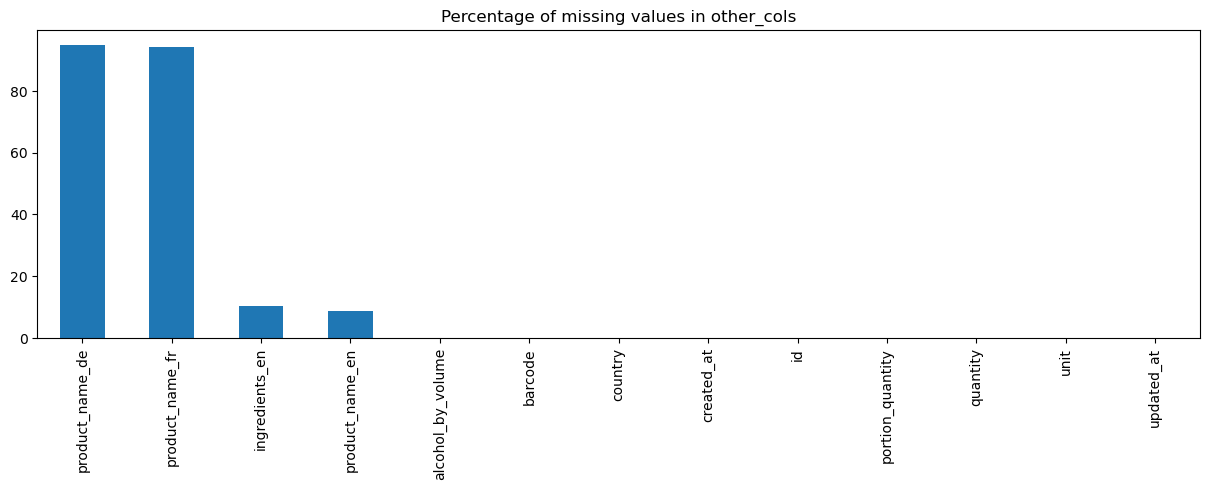

In [14]:
missing_percentage[other_cols].sort_values(ascending=False).plot(kind="bar", figsize=(15, 4), title="Percentage of missing values in other_cols")
plt.show()

**3. We found some missing values let's addressing them and cleaning them step by step.**

3 a). Firstly, removing rows and columns that are completely empty.

In [15]:
# changing the name of dataframe from df_remove_duplicates to df_clean and makking a copy of it.
df_clean = df_remove_duplicates.copy()

In [16]:
# removing the columns that are completely empty
df_clean.dropna(how='all', axis=1)
df_clean.shape

(374884, 99)

In [17]:
# removing the rows that are completely empty
df_clean.dropna(how='all',axis=0)
df_clean.shape


(374884, 99)

3 b) Let's check columns one by one and filling the mising values with more frequent values.

In [18]:
# First checking unit cols**
unit_cols = [col for col in df_clean.columns if col.endswith('_unit')]
df_clean[unit_cols].head()

,calcium_unit,carbohydrates_unit,cholesterol_unit,copper_cu_unit,energy_kcal_unit,energy_unit,fat_unit,fatty_acids_total_saturated_unit,fatty_acids_total_trans_unit,fiber_insoluble_unit,...,vitamin_a_iu_unit,vitamin_b12_cobalamin_unit,vitamin_b1_thiamin_unit,vitamin_b2_riboflavin_unit,vitamin_b3_niacin_unit,vitamin_b5_panthothenic_acid_unit,vitamin_b6_pyridoxin_unit,vitamin_c_ascorbic_acid_unit,vitamin_d_d2_d3_international_units_unit,zinc_unit
0,NaN,g,NaN,NaN,kCal,kJ,g,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,g,NaN,NaN,kCal,kJ,g,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,g,NaN,NaN,kCal,kJ,g,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,g,NaN,NaN,kCal,kJ,g,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,g,NaN,NaN,kCal,kJ,g,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


As we can see there are lots of nan values, let's replace them with most frequet value from the respective columns

In [19]:
for col in unit_cols:
    most_frequent_value = df_clean[col].mode()[0]
    df_clean.fillna({col: most_frequent_value}, inplace=True) 

df_clean[unit_cols].head()

,calcium_unit,carbohydrates_unit,cholesterol_unit,copper_cu_unit,energy_kcal_unit,energy_unit,fat_unit,fatty_acids_total_saturated_unit,fatty_acids_total_trans_unit,fiber_insoluble_unit,...,vitamin_a_iu_unit,vitamin_b12_cobalamin_unit,vitamin_b1_thiamin_unit,vitamin_b2_riboflavin_unit,vitamin_b3_niacin_unit,vitamin_b5_panthothenic_acid_unit,vitamin_b6_pyridoxin_unit,vitamin_c_ascorbic_acid_unit,vitamin_d_d2_d3_international_units_unit,zinc_unit
0,mg,g,mg,mg,kCal,kJ,g,g,g,g,...,IU,µg,mg,mg,mg,mg,mg,mg,IU,mg
1,mg,g,mg,mg,kCal,kJ,g,g,g,g,...,IU,µg,mg,mg,mg,mg,mg,mg,IU,mg
2,mg,g,mg,mg,kCal,kJ,g,g,g,g,...,IU,µg,mg,mg,mg,mg,mg,mg,IU,mg
3,mg,g,mg,mg,kCal,kJ,g,g,g,g,...,IU,µg,mg,mg,mg,mg,mg,mg,IU,mg
4,mg,g,mg,mg,kCal,kJ,g,g,g,g,...,IU,µg,mg,mg,mg,mg,mg,mg,IU,mg


3 c). Now, checking missing values in _product_name_en_ column and filling with some similar values from other columns.

In [20]:
# Replacing the mising values in product_name_en with product_name_fr and product_name_de
df_clean.fillna({"product_name_en" : df_clean["product_name_fr"]}, inplace=True)
df_clean.fillna({"product_name_en" : df_clean["product_name_de"]}, inplace=True)
duplicate_count_fr = (df_clean['product_name_en'] == df_clean['product_name_fr']).sum()
duplicate_count_de = (df_clean['product_name_en'] == df_clean['product_name_de']).sum()

print(f"number of rows that are filled up is:{duplicate_count_fr + duplicate_count_de}")

number of rows that are filled up is:17865


3 d) Checking the missing value in the column named _iron_per_hundred_.

In [21]:
print("Number of missing values in iron_per_hundered:",df_clean['iron_per_hundred'].isnull().sum())

Number of missing values in iron_per_hundered: 110495


As we can see there are lots of nan values so i am replacig them with 0.

In [22]:
df_clean.fillna({'iron_per_hundred' :0.0}, inplace=True)

3 e) The column _ingredients_en_ has about 10% missing values. Let’s replace them with the term _ingredient_missing_

In [23]:
df_clean.fillna({"ingredients_en":"ingredients_missing"}, inplace=True)

3 f) Many coloums have a lots of missing values so I am droping the columns that have more than 95% of missing values and get the shape of the remaining data.

In [24]:
#First checking the Shape fo the data frame before dropping the columns.
print("Shape fo the data frame before dropping the columns:", df_clean.shape)
df_clean.shape

Shape fo the data frame before dropping the columns: (374884, 99)


(374884, 99)

In [25]:
df_new = df_clean.dropna(thresh= int(df_clean.shape[0] * 0.05), axis=1)
print("Shape fo the data frame after dropping the columns:", df_new.shape)


Shape fo the data frame after dropping the columns: (374884, 77)


As we have cleaned the some columns  which have nan values, so now checking the rest of columns for nan values.

In [26]:
df_new.isnull().sum()

alcohol_by_volume                                       0
barcode                                                 0
calcium_per_hundred                                110030
calcium_unit                                            0
carbohydrates_per_hundred                           26333
                                                    ...  
vitamin_c_ascorbic_acid_per_hundred                174878
vitamin_c_ascorbic_acid_unit                            0
vitamin_d_d2_d3_international_units_per_hundred    307860
vitamin_d_d2_d3_international_units_unit                0
zinc_unit                                               0
Length: 77, dtype: int64

Here, I can see there are some columns that have nan values, I am treating them in the next task.

## Task C. Preliminary Exploratory Data Analysis (EDA)


**1. I am explore here the categorical variables in more detail.**

In [27]:
categorical_cols_all = df_new.select_dtypes(include=['object', 'category']).columns
unique_values = df_new[categorical_cols_all].nunique()
print("Number of unique values in each categorical variable:")
print(unique_values)


Number of unique values in each categorical variable:
barcode                                     374446
calcium_unit                                     1
carbohydrates_unit                               1
cholesterol_unit                                 1
copper_cu_unit                                   1
country                                          7
created_at                                   46990
energy_kcal_unit                                 1
energy_unit                                      1
fat_unit                                         1
fatty_acids_total_saturated_unit                 1
fatty_acids_total_trans_unit                     1
fiber_insoluble_unit                             1
fiber_soluble_unit                               1
fiber_unit                                       1
folate_total_unit                                1
folic_acid_unit                                  1
hundred_unit                                     3
ingredients_en              

Showing the proportion of samples in each categorical level in the variables _country_ and _unit_ using appropriate visualizations.

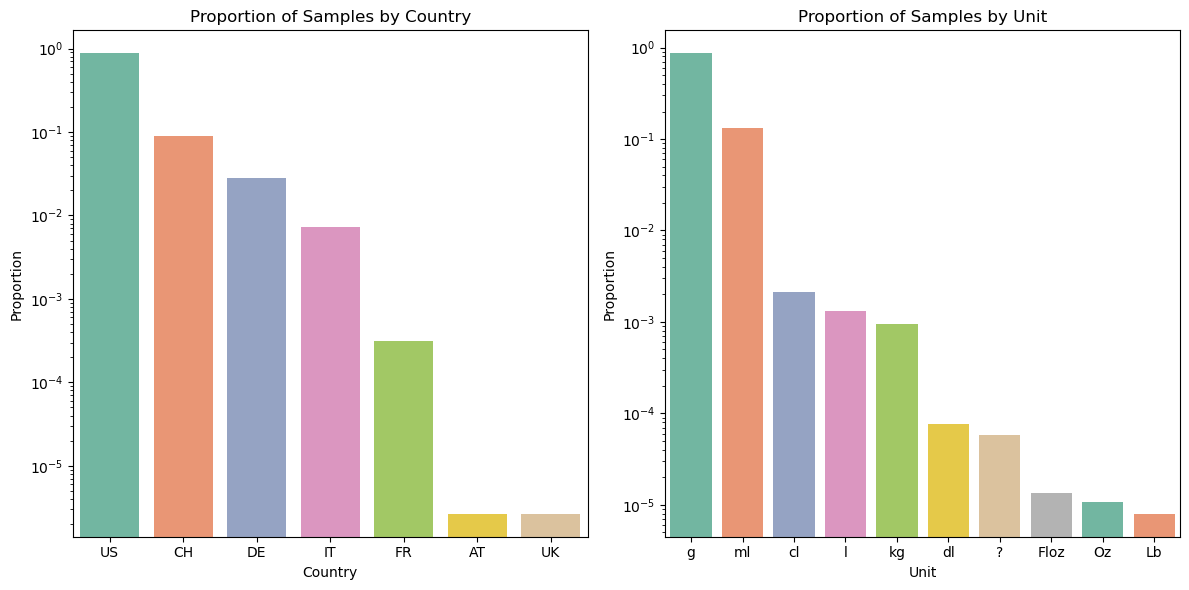

In [28]:
categorical_cols = ['country', 'unit']
country_proportions = df_new['country'].value_counts(normalize=True)
unit_proportions = df_new['unit'].value_counts(normalize=True)

plt.figure(figsize=(12, 6))
# First subplot: Proportion of Samples by Country
plt.subplot(1, 2, 1)
sns.barplot(x=country_proportions.index, y=country_proportions.values, hue =country_proportions.index,  palette="Set2", legend=False)
plt.title('Proportion of Samples by Country')
plt.xlabel('Country')
plt.ylabel('Proportion')
plt.yscale('log')  

# Second subplot: Proportion of Samples by Unit
plt.subplot(1, 2, 2)
sns.barplot(x=unit_proportions.index, y=unit_proportions.values, hue=unit_proportions.index,  palette="Set2",legend=False)
plt.title('Proportion of Samples by Unit')
plt.xlabel('Unit')
plt.ylabel('Proportion')
plt.yscale('log')  # log scale to better visualize the differences
plt.tight_layout()
plt.show()



Here in these plots, after using the log scale, I can clearly visualize the data for all countries i.e proportion of samples in each country.

In [29]:
# Here I am making of copy of the data frame df_new (keeping the name same to avoid confusion)
df_new = df_new.copy()

In [30]:
numerical_col = df_new.select_dtypes(include=["number"]).columns

In [31]:
columns_with_nan = df_new.columns[df_new.isnull().sum() > 0]
columns_with_nan


Index(['calcium_per_hundred', 'carbohydrates_per_hundred',
       'cholesterol_per_hundred', 'energy_kcal_per_hundred',
       'energy_per_hundred', 'fat_per_hundred',
       'fatty_acids_total_saturated_per_hundred',
       'fatty_acids_total_trans_per_hundred', 'fiber_per_hundred',
       'monounsaturated_fatty_acids_per_hundred',
       'polyunsaturated_fatty_acids_per_hundred', 'potassium_k_per_hundred',
       'product_name_de', 'product_name_en', 'product_name_fr',
       'protein_per_hundred', 'salt_per_hundred', 'saturated_fat_per_hundred',
       'sodium_per_hundred', 'sugars_added_per_hundred', 'sugars_per_hundred',
       'vitamin_a_iu_per_hundred', 'vitamin_b1_thiamin_per_hundred',
       'vitamin_b2_riboflavin_per_hundred', 'vitamin_b3_niacin_per_hundred',
       'vitamin_c_ascorbic_acid_per_hundred',
       'vitamin_d_d2_d3_international_units_per_hundred'],
      dtype='object')

Here, I can use the numrical_col, which has all numerical columns  but I am choosing to use the columns_with_nan for some generalization.

In [32]:
for column in columns_with_nan:
    if df_new[column].dtype in ['float64', 'int64']: 
        df_new.fillna({column:df_new[column].mean()}, inplace=True)

# Display the updated DataFrame
df_new

,alcohol_by_volume,barcode,calcium_per_hundred,calcium_unit,carbohydrates_per_hundred,carbohydrates_unit,cholesterol_per_hundred,cholesterol_unit,copper_cu_unit,country,...,vitamin_b2_riboflavin_unit,vitamin_b3_niacin_per_hundred,vitamin_b3_niacin_unit,vitamin_b5_panthothenic_acid_unit,vitamin_b6_pyridoxin_unit,vitamin_c_ascorbic_acid_per_hundred,vitamin_c_ascorbic_acid_unit,vitamin_d_d2_d3_international_units_per_hundred,vitamin_d_d2_d3_international_units_unit,zinc_unit
0,0.0,8001772000030,116.647405,mg,75.000000,g,58.981358,mg,mg,CH,...,mg,9.846486,mg,mg,mg,15.704688,mg,14.186515,IU,mg
1,0.0,7610809001066,116.647405,mg,1.500000,g,58.981358,mg,mg,CH,...,mg,9.846486,mg,mg,mg,15.704688,mg,14.186515,IU,mg
2,0.0,8002530159021,116.647405,mg,52.680000,g,58.981358,mg,mg,CH,...,mg,9.846486,mg,mg,mg,15.704688,mg,14.186515,IU,mg
3,0.0,3033715065788,116.647405,mg,70.400000,g,58.981358,mg,mg,CH,...,mg,9.846486,mg,mg,mg,15.704688,mg,14.186515,IU,mg
4,0.0,7610848492740,116.647405,mg,37.000000,g,58.981358,mg,mg,CH,...,mg,9.846486,mg,mg,mg,15.704688,mg,14.186515,IU,mg
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
374879,0.0,7640145040283,116.647405,mg,34.005231,g,58.981358,mg,mg,CH,...,mg,9.846486,mg,mg,mg,15.704688,mg,14.186515,IU,mg
374880,0.0,7640147023628,850.000000,mg,48.600000,g,58.981358,mg,mg,CH,...,mg,120.000000,mg,mg,mg,500.000000,mg,14.186515,IU,mg
374881,0.0,3046920021593,116.647405,mg,22.000000,g,58.981358,mg,mg,CH,...,mg,9.846486,mg,mg,mg,15.704688,mg,14.186515,IU,mg
374882,0.0,4044889004335,116.647405,mg,34.005231,g,58.981358,mg,mg,CH,...,mg,9.846486,mg,mg,mg,15.704688,mg,14.186515,IU,mg


**2.Checking descriptive statistics (e.g., min/max/mean).**

In [33]:
df_new.describe()

,alcohol_by_volume,calcium_per_hundred,carbohydrates_per_hundred,cholesterol_per_hundred,energy_kcal_per_hundred,energy_per_hundred,fat_per_hundred,fatty_acids_total_saturated_per_hundred,fatty_acids_total_trans_per_hundred,fiber_per_hundred,...,saturated_fat_per_hundred,sodium_per_hundred,sugars_added_per_hundred,sugars_per_hundred,vitamin_a_iu_per_hundred,vitamin_b1_thiamin_per_hundred,vitamin_b2_riboflavin_per_hundred,vitamin_b3_niacin_per_hundred,vitamin_c_ascorbic_acid_per_hundred,vitamin_d_d2_d3_international_units_per_hundred
count,374884.000000,374884.000000,374884.000000,374884.000000,374884.000000,374884.000000,374884.000000,374884.000000,374884.000000,374884.000000,...,374884.000000,374884.000000,374884.000000,374884.000000,374884.000000,374884.000000,374884.000000,374884.000000,374884.000000,374884.000000
mean,0.027911,116.647405,34.005231,58.981358,272.484231,1139.512786,12.705385,4.943331,0.034861,2.925621,...,5.904191,1.402169,23.993521,16.992009,494.236708,0.925326,1.680103,9.846486,15.704688,14.186515
std,0.769066,2150.006940,39.388185,1642.773830,245.460644,1026.053362,18.722194,7.335202,1.090046,5.133230,...,1.963513,64.908122,8.622674,29.257484,1750.371520,3.146998,32.676652,17.344118,426.303402,30.977467
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,12.000000,7.200000,0.000000,104.000000,435.140000,0.000000,0.000000,0.000000,0.000000,...,5.904191,0.050000,23.993521,2.160000,0.000000,0.925326,1.680103,9.846486,0.000000,14.186515
50%,0.000000,88.000000,28.350000,15.000000,272.484231,1139.512786,7.600000,4.943331,0.000000,2.900000,...,5.904191,0.340000,23.993521,9.380000,494.236708,0.925326,1.680103,9.846486,15.704688,14.186515
75%,0.000000,116.647405,57.140000,58.981358,393.000000,1644.310000,18.180000,5.130000,0.034861,3.100000,...,5.904191,0.850000,23.993521,21.700000,494.236708,0.925326,1.680103,9.846486,15.704688,14.186515
max,57.900000,684000.000000,6400.000000,250000.000000,39600.000000,165686.400000,3200.000000,1000.000000,615.380000,1730.000000,...,100.000000,25833.330000,1100.000000,5800.000000,333333.000000,1111.000000,20000.000000,6785.710000,210000.000000,5000.000000


1. By looking at the standard deviation values, in some of the columns, there is a lot of variation in the data. 
2. There are huge difference between the values of 75 precentile and max in some of the columns (such as calcium _per_hundered, cholesterol_per_hundered etc). which indicates that there are outliers present in the data of those columns.

**To investigate more about the data, I am plotting the histogram plots of all the columns**



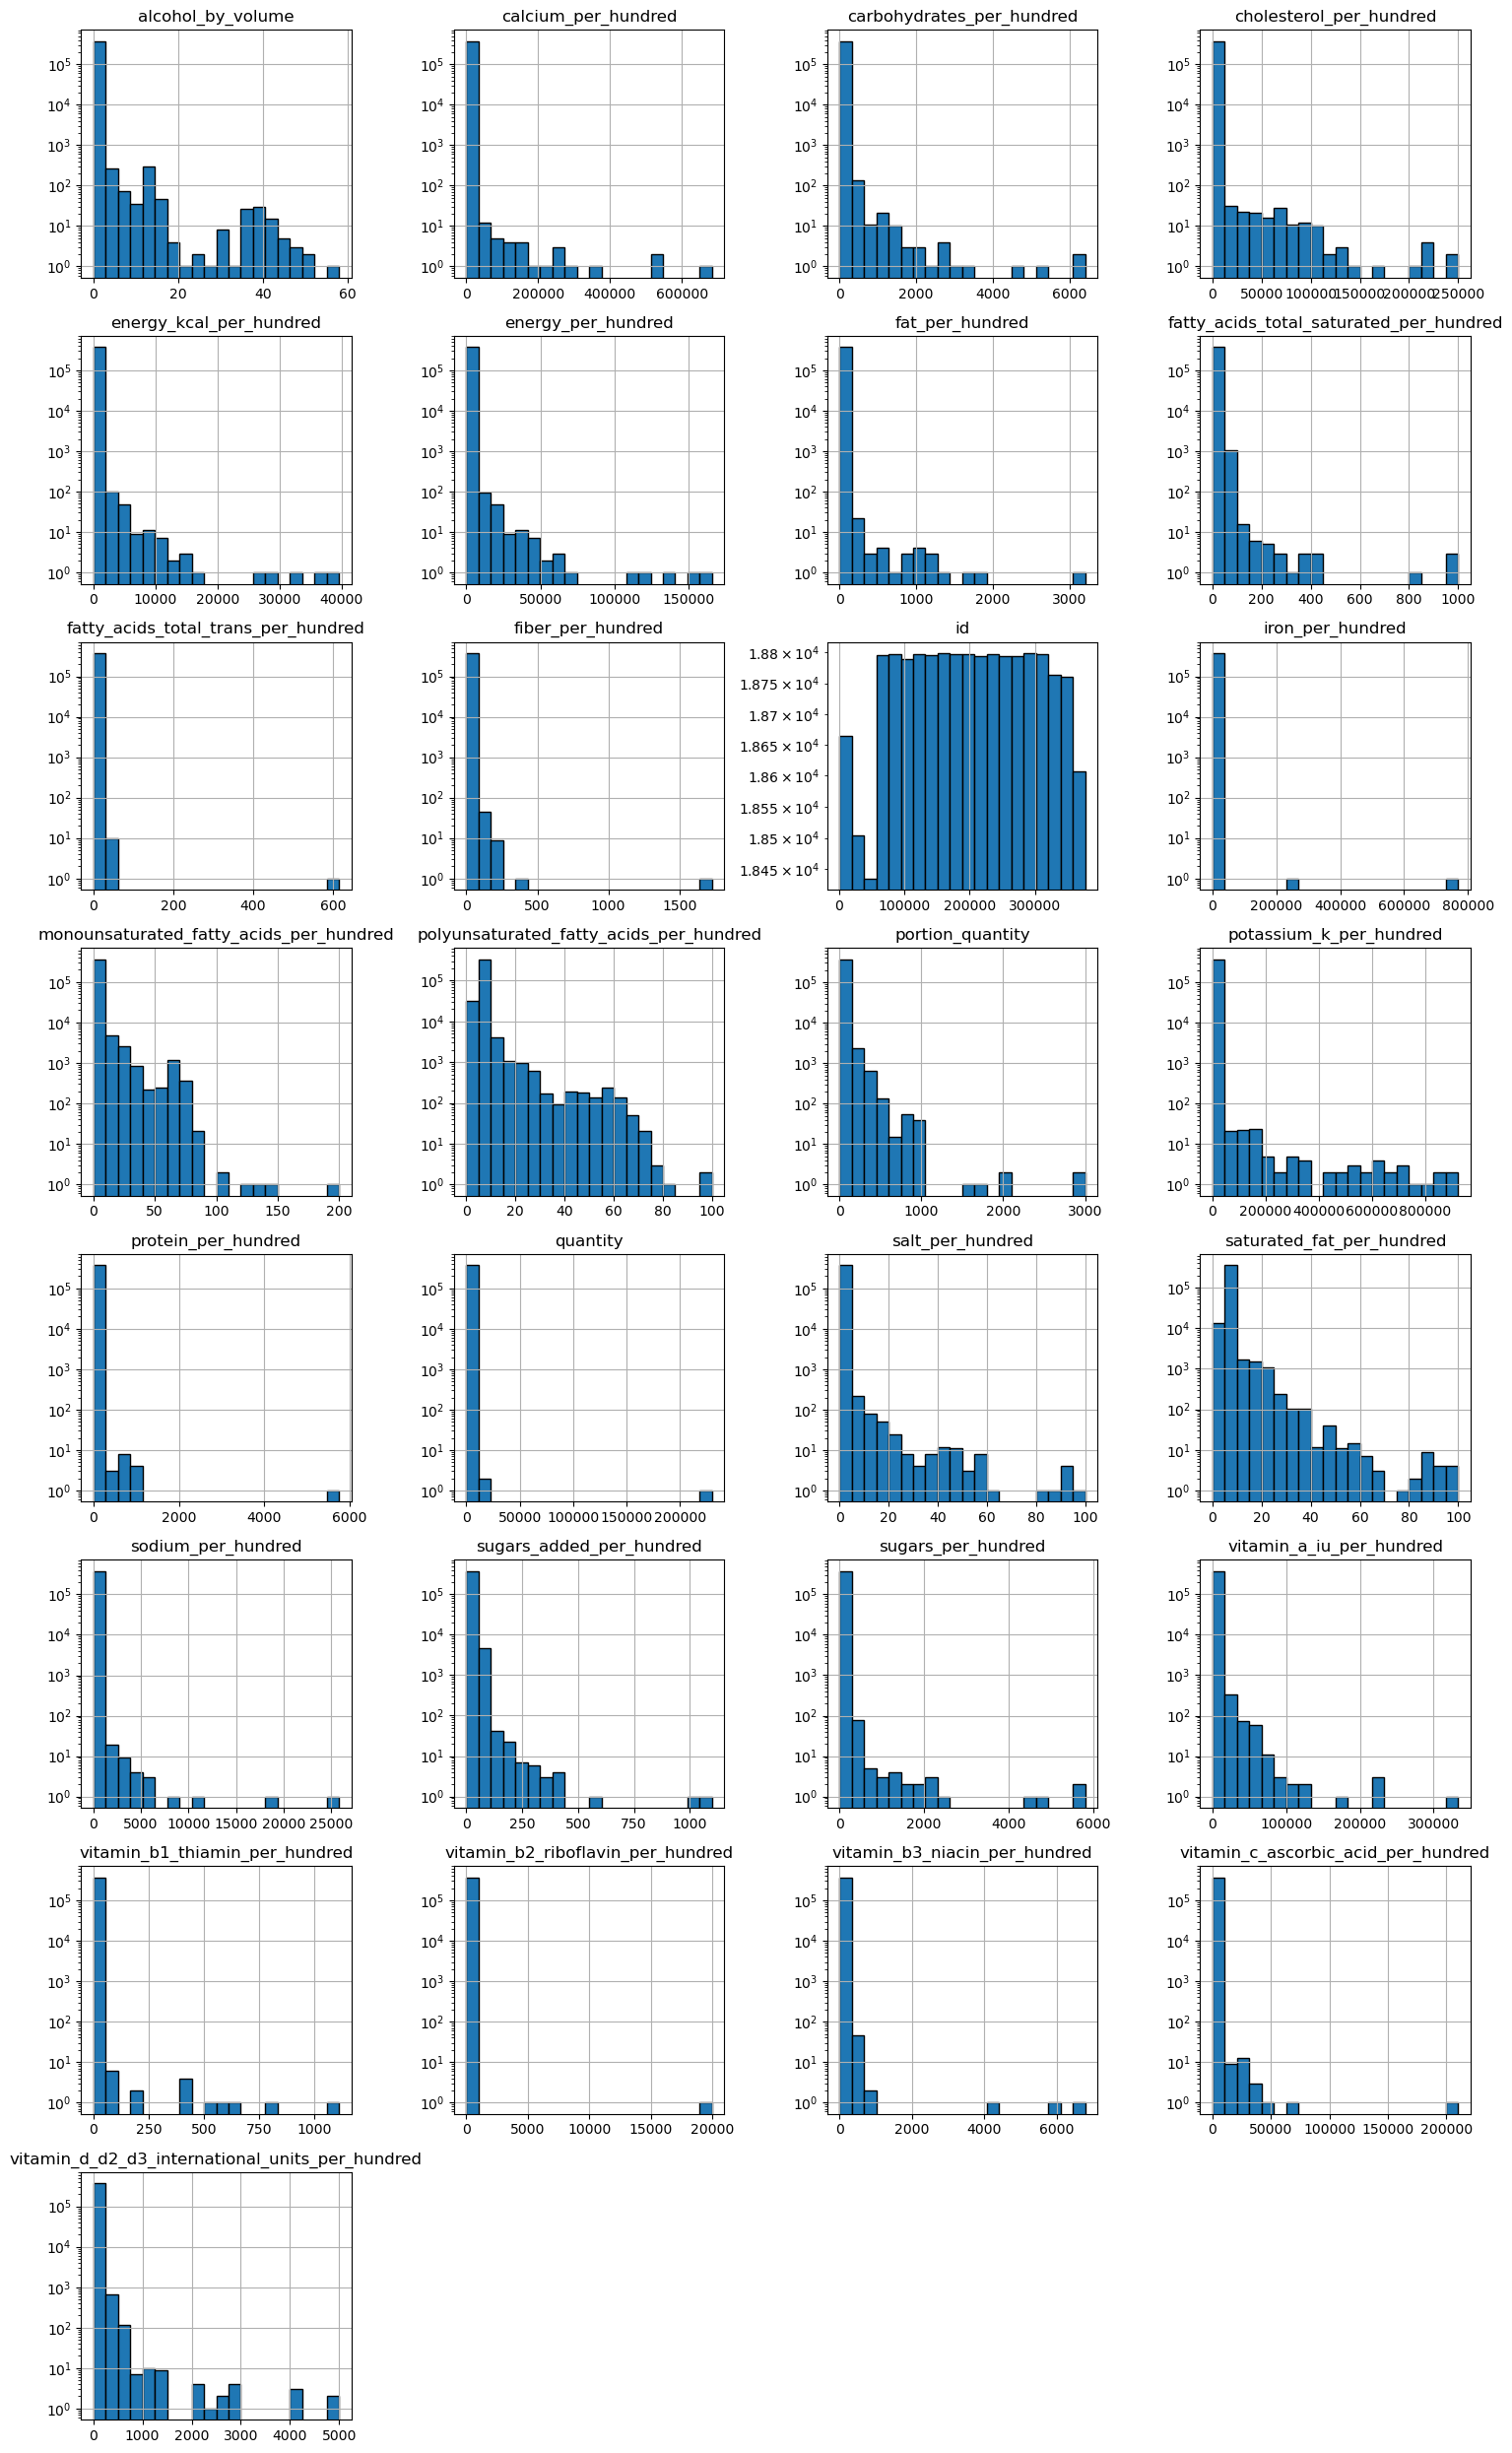

In [34]:
df_new[numerical_col].hist(bins=20, figsize=(15, 25), layout=(-1, 4), edgecolor="black")

# Set the y-axis to be in log scale to better visualize the distribution of the data
for ax in plt.gcf().axes:
    ax.set_yscale('log')

plt.tight_layout()
plt.show()

From the above bar plots, it can be clearly seen that there are outliers presented in the data 

**3. There are many problematic values to check. Addressing them one by one, Using the statistics and  plots of the per_hundred columns.**

Reseting the index of the dataframe.

In [35]:
df_reset = df_new.reset_index(drop=True)

In [36]:
per_hundred_cols = [col for col in df_reset.columns if col.endswith('_per_hundred')]
per_portion_cols = [col for col in df_reset.columns if col.endswith('_per_portion')]
unit_cols = [col for col in df_reset.columns if col.endswith('_unit')]
other_cols = [col for col in df_reset.columns if not col.endswith(('_unit', '_per_portion', '_per_hundred'))]

print("Columns ending with '_per_hundred':", per_hundred_cols)
print("Columns ending with '_per_portion':", per_portion_cols)
print("Columns ending with '_unit':", unit_cols)
print("Other columns:", other_cols)

Columns ending with '_per_hundred': ['calcium_per_hundred', 'carbohydrates_per_hundred', 'cholesterol_per_hundred', 'energy_kcal_per_hundred', 'energy_per_hundred', 'fat_per_hundred', 'fatty_acids_total_saturated_per_hundred', 'fatty_acids_total_trans_per_hundred', 'fiber_per_hundred', 'iron_per_hundred', 'monounsaturated_fatty_acids_per_hundred', 'polyunsaturated_fatty_acids_per_hundred', 'potassium_k_per_hundred', 'protein_per_hundred', 'salt_per_hundred', 'saturated_fat_per_hundred', 'sodium_per_hundred', 'sugars_added_per_hundred', 'sugars_per_hundred', 'vitamin_a_iu_per_hundred', 'vitamin_b1_thiamin_per_hundred', 'vitamin_b2_riboflavin_per_hundred', 'vitamin_b3_niacin_per_hundred', 'vitamin_c_ascorbic_acid_per_hundred', 'vitamin_d_d2_d3_international_units_per_hundred']
Columns ending with '_per_portion': []
Columns ending with '_unit': ['calcium_unit', 'carbohydrates_unit', 'cholesterol_unit', 'copper_cu_unit', 'energy_kcal_unit', 'energy_unit', 'fat_unit', 'fatty_acids_total_sat

Checking the length of each colounms.

In [37]:
print(f"length of each columns before")
print(len(unit_cols), len(per_hundred_cols), len(per_portion_cols), len(other_cols))

length of each columns before
39 25 0 13


Unit columns and per hundered columns are not in same length, removing the unit coloumns that are not needed.

In [38]:
new_unit_cols = []
remove_unit_cols = []
for col in per_hundred_cols:
    unit_col = col.replace('_per_hundred', '_unit')
    if unit_col in unit_cols:
        new_unit_cols.append(unit_col)


# creating another list to remove the unit columns that are not needed
for col in unit_cols:
    if col not in new_unit_cols:
        remove_unit_cols.append(col)

print(len(new_unit_cols), len(per_hundred_cols), len(per_portion_cols), len(other_cols), len(remove_unit_cols))

25 25 0 13 14


Reseting the data and removing _unit_cols that are not needed.

In [39]:
df_reset.drop(columns=remove_unit_cols, inplace=True)
df_reset.shape


(374884, 63)

Making some plots to check the values in the columns, I am treating these values in the next line and rechecking again to confirm the change.

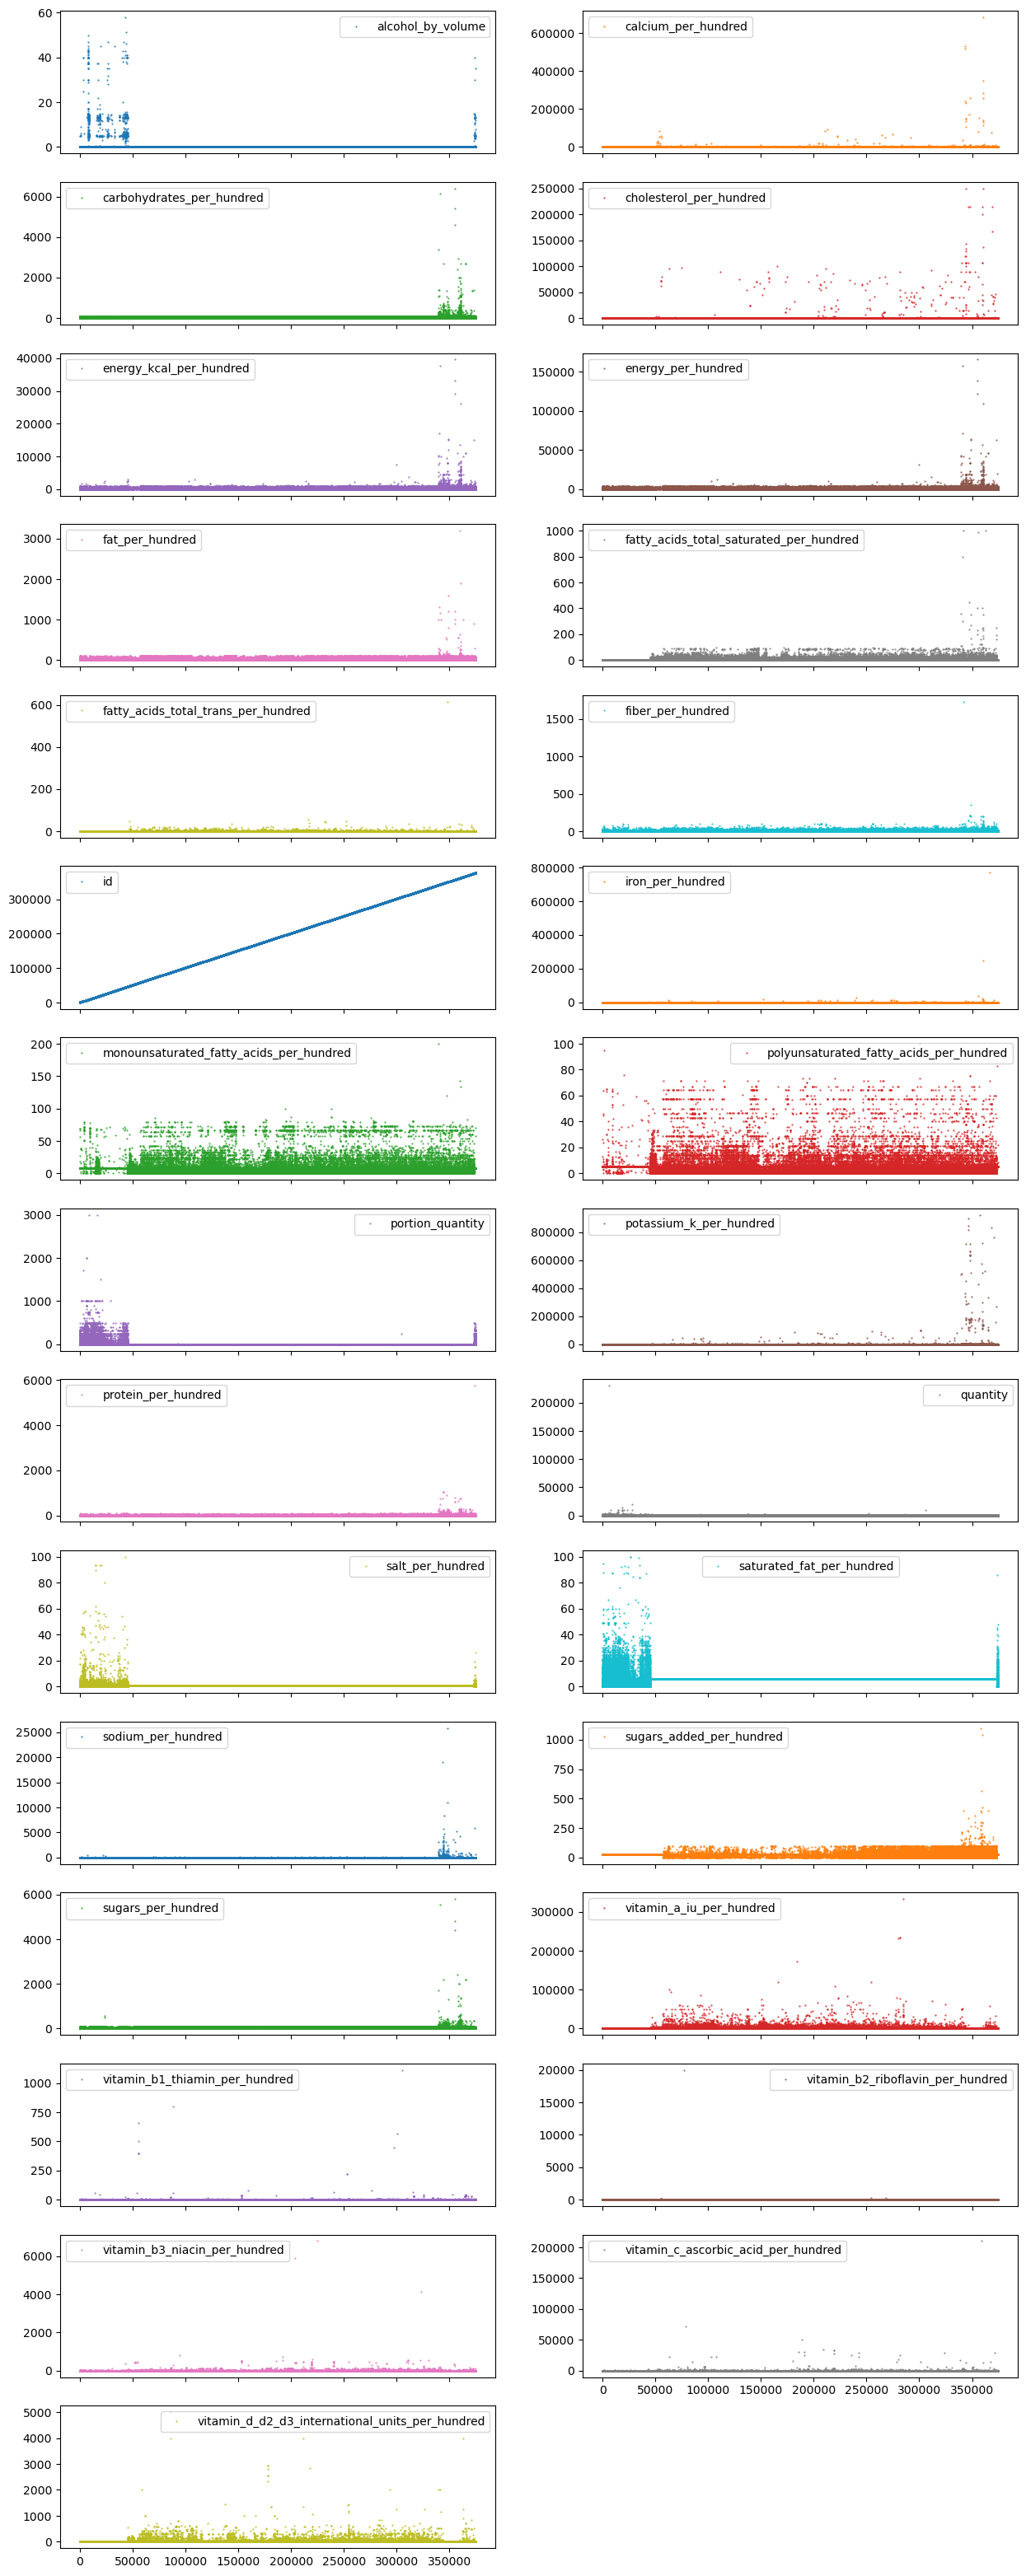

In [40]:
df_reset.plot(lw=0, marker=".", subplots=True, layout=(-1, 2), figsize=(15, 40), markersize=1);

As we can see in the above plots, that they are showing out of range values for each _per_hundered columns. Here, I am droping those are higher than the limit values.

In [41]:
unit_limits = {
    'g': 100,
    'mg': 1e5,
    'ug': 1e8,
    'kJ': 3700,
    'kCal': 885    
}

for col in new_unit_cols:   
    unit = df_reset[col].iloc[0]       
    if unit in unit_limits:
        col_t = col.replace("_unit", "_per_hundred")
        threshold = unit_limits[unit]               
        entries_to_drop = df_reset[col_t].gt(threshold)
        df_reset = df_reset[~entries_to_drop]


# treating IU unit columns seprately
limit_IU_Vit_A =  3.3e8
limit_IU_Vit_D = 4.0e9

Vit_A_col = "vitamin_a_iu_per_hundred"
Vit_D_col = "vitamin_d_d2_d3_international_units_per_hundred"

entries_to_drop_Vit_A = df_reset[Vit_A_col].gt(limit_IU_Vit_A)
df_reset = df_reset[~entries_to_drop_Vit_A]

entries_to_drop_Vit_D = df_reset[Vit_D_col].gt(limit_IU_Vit_D)
df_reset = df_reset[~entries_to_drop_Vit_D]

df_reset.describe()


,alcohol_by_volume,calcium_per_hundred,carbohydrates_per_hundred,cholesterol_per_hundred,energy_kcal_per_hundred,energy_per_hundred,fat_per_hundred,fatty_acids_total_saturated_per_hundred,fatty_acids_total_trans_per_hundred,fiber_per_hundred,...,saturated_fat_per_hundred,sodium_per_hundred,sugars_added_per_hundred,sugars_per_hundred,vitamin_a_iu_per_hundred,vitamin_b1_thiamin_per_hundred,vitamin_b2_riboflavin_per_hundred,vitamin_b3_niacin_per_hundred,vitamin_c_ascorbic_acid_per_hundred,vitamin_d_d2_d3_international_units_per_hundred
count,372842.000000,372842.000000,372842.000000,372842.000000,372842.000000,372842.000000,372842.000000,372842.000000,372842.000000,372842.000000,...,372842.000000,372842.000000,372842.000000,372842.000000,372842.000000,372842.000000,372842.000000,372842.000000,372842.000000,372842.000000
mean,0.028063,102.981704,33.375714,47.163332,268.313469,1122.417513,12.480737,4.871617,0.032648,2.893273,...,5.900046,0.796324,23.940572,16.633425,493.091272,0.925148,1.679906,9.843521,15.027612,14.152876
std,0.771167,438.321642,28.140469,1001.368422,178.226555,745.427254,15.983493,6.142654,0.403472,3.987678,...,1.903477,2.740361,7.747041,20.102718,1744.370952,3.155484,32.765994,17.384719,251.989560,29.753878
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,12.000000,7.200000,0.000000,104.000000,435.000000,0.000000,0.000000,0.000000,0.000000,...,5.904191,0.050000,23.993521,2.160000,0.000000,0.925326,1.680103,9.846486,0.000000,14.186515
50%,0.000000,88.000000,28.190000,15.000000,272.484231,1139.512786,7.500000,4.943331,0.000000,2.900000,...,5.904191,0.340000,23.993521,9.370000,494.236708,0.925326,1.680103,9.846486,15.704688,14.186515
75%,0.000000,116.647405,57.140000,58.981358,393.000000,1644.310000,18.000000,5.040000,0.034861,3.100000,...,5.904191,0.840000,23.993521,21.540000,494.236708,0.925326,1.680103,9.846486,15.704688,14.186515
max,57.900000,93750.000000,100.000000,100000.000000,885.000000,3700.000000,100.000000,100.000000,53.570000,100.000000,...,100.000000,100.000000,100.000000,100.000000,333333.000000,1111.000000,20000.000000,6785.710000,71428.600000,5000.000000


After removing the data out of range, the above description of the data reveals that the values in each columns are in the range. Here I am plotting again to  visually verifying  that each per_hundered columns has values within the max limit.

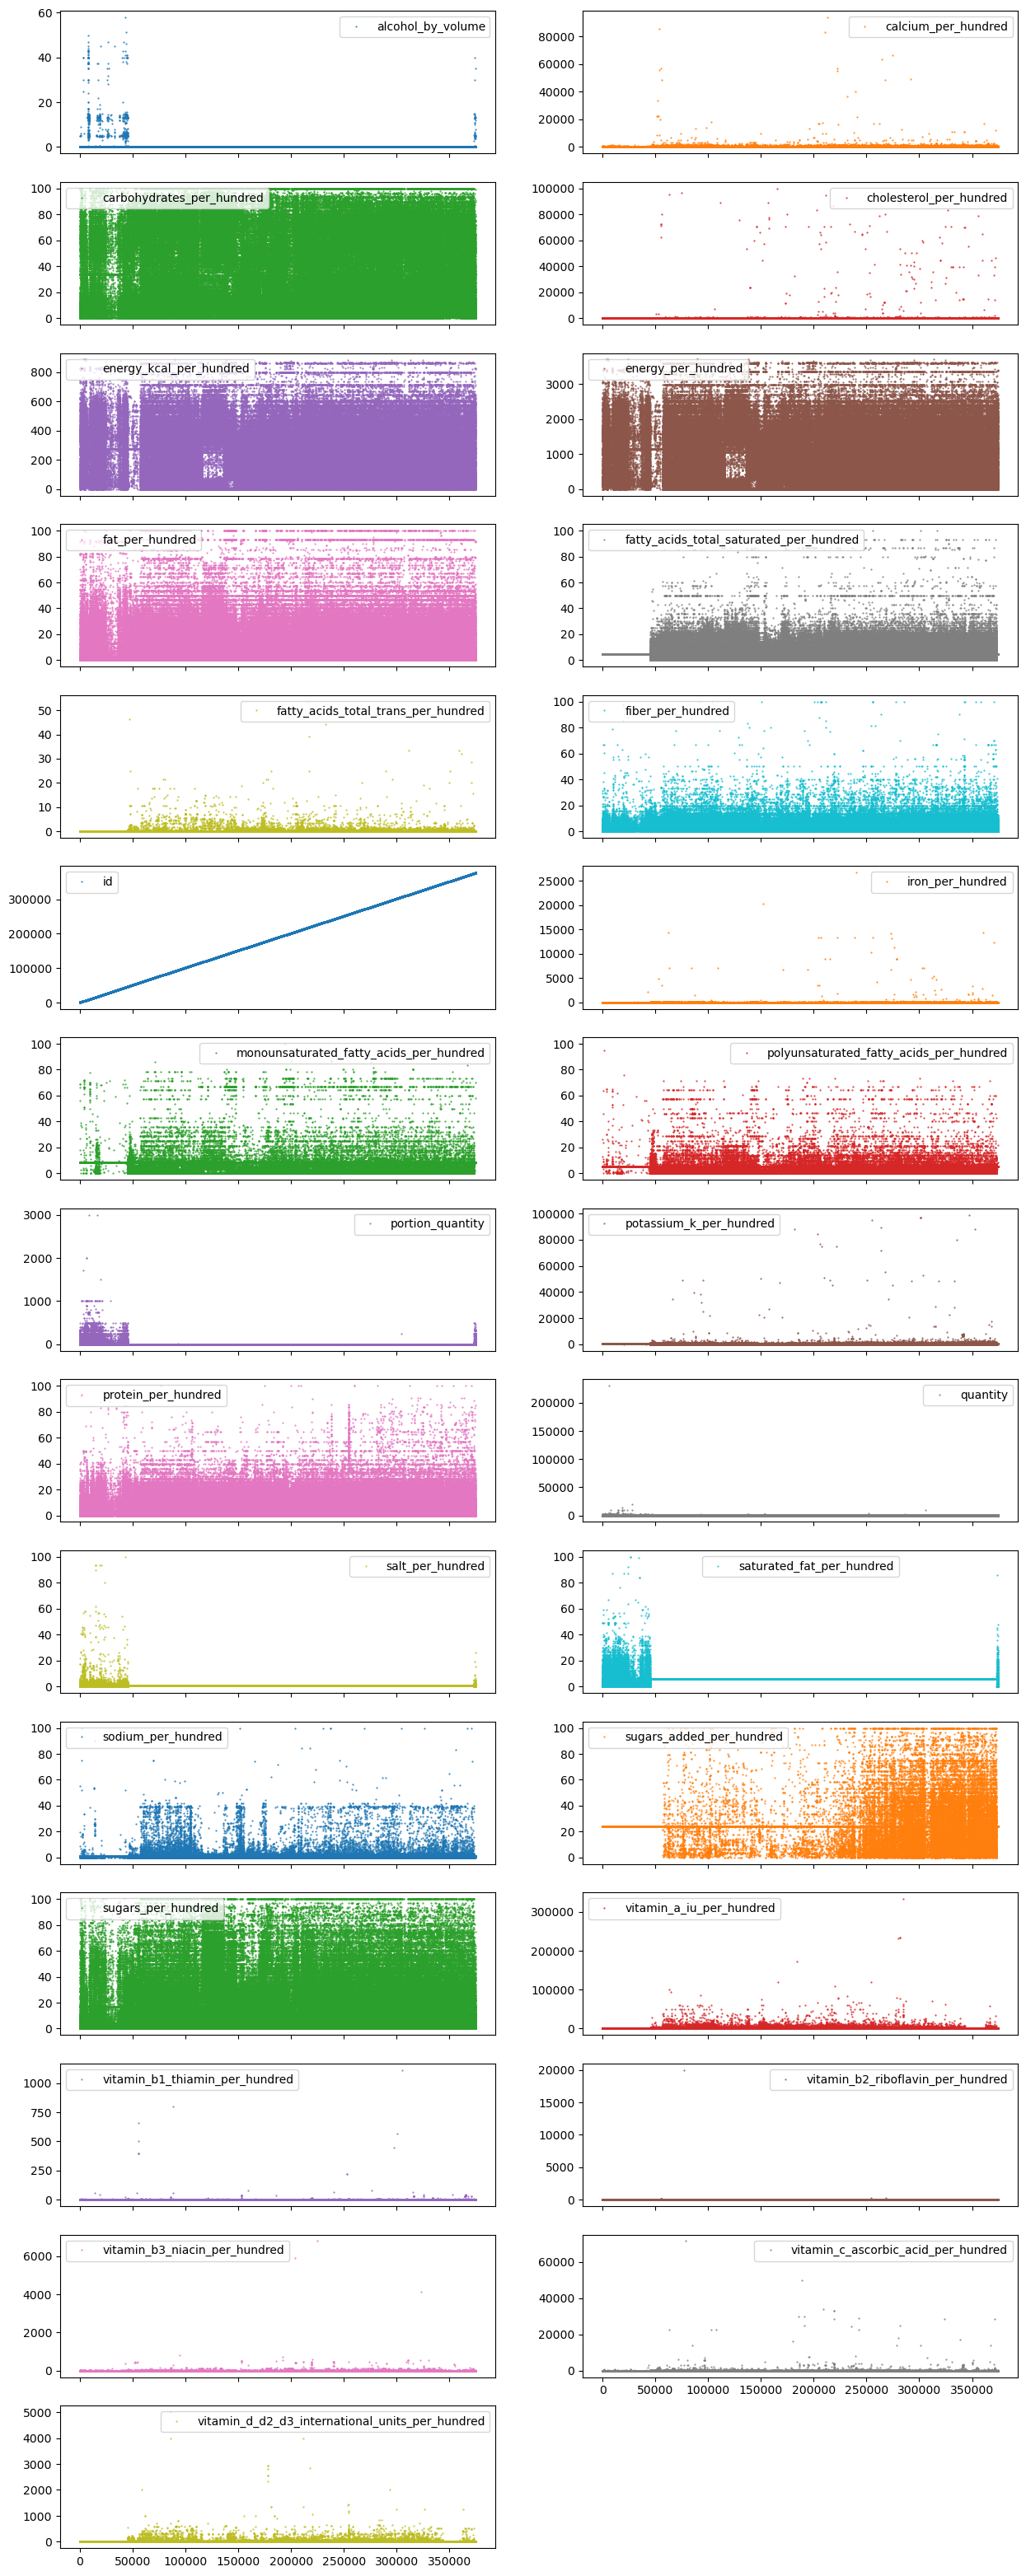

In [42]:
df_reset.plot(lw=0, marker=".", subplots=True, layout=(-1, 2), figsize=(15, 40), markersize=1);

From the plots, It can be observed that the values are in the max limit range for the _per_hundered_columns but it seems that there are ouliers in the data. One such case is analysing in the next part. 


**4. Investigating the some cases below analytically and identify is there any potential inconsistencies if yes then trying to address them.**

In [43]:
df_reset[per_hundred_cols].head()

,calcium_per_hundred,carbohydrates_per_hundred,cholesterol_per_hundred,energy_kcal_per_hundred,energy_per_hundred,fat_per_hundred,fatty_acids_total_saturated_per_hundred,fatty_acids_total_trans_per_hundred,fiber_per_hundred,iron_per_hundred,...,saturated_fat_per_hundred,sodium_per_hundred,sugars_added_per_hundred,sugars_per_hundred,vitamin_a_iu_per_hundred,vitamin_b1_thiamin_per_hundred,vitamin_b2_riboflavin_per_hundred,vitamin_b3_niacin_per_hundred,vitamin_c_ascorbic_acid_per_hundred,vitamin_d_d2_d3_international_units_per_hundred
0,116.647405,75.00,58.981358,359.0,1500.0,0.42,4.943331,0.034861,2.925621,0.0,...,5.904191,1.402169,23.993521,16.992009,494.236708,0.925326,1.680103,9.846486,15.704688,14.186515
1,116.647405,1.50,58.981358,242.0,1010.0,18.00,4.943331,0.034861,0.000000,0.0,...,11.000000,1.402169,23.993521,1.500000,494.236708,0.925326,1.680103,9.846486,15.704688,14.186515
2,116.647405,52.68,58.981358,325.0,1358.3,12.08,4.943331,0.034861,2.925621,0.0,...,3.030000,1.402169,23.993521,0.250000,494.236708,0.925326,1.680103,9.846486,15.704688,14.186515
3,116.647405,70.40,58.981358,402.0,1679.0,7.90,4.943331,0.034861,9.100000,0.0,...,4.200000,1.402169,23.993521,65.800000,494.236708,0.925326,1.680103,9.846486,15.704688,14.186515
4,116.647405,37.00,58.981358,591.0,2470.0,44.00,4.943331,0.034861,9.000000,0.0,...,27.000000,1.402169,23.993521,29.000000,494.236708,0.925326,1.680103,9.846486,15.704688,14.186515


4. a) Checking the combination of four main macronutrients (fat, protein, carbohydrates and fiber) in per hundered.

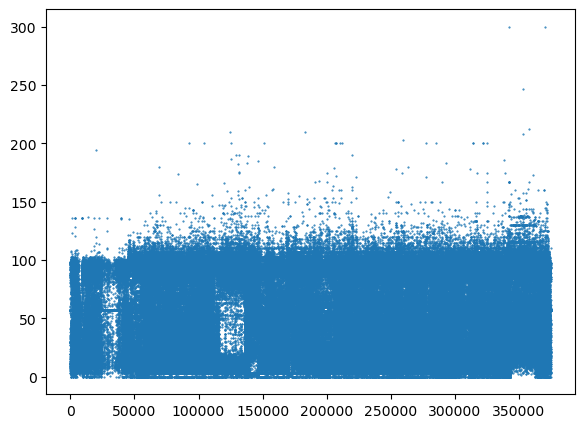

In [44]:
macronutrient_columns = df_reset['fat_per_hundred'] + df_reset['protein_per_hundred'] + df_reset['carbohydrates_per_hundred'] + df_reset['fiber_per_hundred']

macronutrient_columns.plot(lw=0, marker=".", subplots=True, layout=(-1, 2), figsize=(15, 5), markersize=1);    


In [45]:
macronutrient_columns.describe()

count    372842.000000
mean         55.887483
std          34.387883
min           0.000000
25%          23.220000
50%          56.887246
75%          91.200000
max         300.000000
dtype: float64

As I can see in above plot and descriptive values of the macronutrient columns data, It has many outliers. Idealy it should has max value of 100 but there are many values which are more than 100, so next I am trying to resolve them.

In [46]:
df_reset[['fat_per_hundred', 'protein_per_hundred', 'carbohydrates_per_hundred', 'fiber_per_hundred']].describe()

,fat_per_hundred,protein_per_hundred,carbohydrates_per_hundred,fiber_per_hundred
count,372842.000000,372842.000000,372842.000000,372842.000000
mean,12.480737,7.137759,33.375714,2.893273
std,15.983493,8.257712,28.140469,3.987678
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.780000,7.200000,0.000000
50%,7.500000,5.130000,28.190000,2.900000
75%,18.000000,9.680000,57.140000,3.100000
max,100.000000,100.000000,100.000000,100.000000


In [47]:
df_reset['macronutrient_columns'] = df_reset['fat_per_hundred'] + df_reset['protein_per_hundred'] + df_reset['carbohydrates_per_hundred'] + df_reset['fiber_per_hundred']

Here I am checking the describe values of the macronutrient columns again.

In [48]:
df_reset['macronutrient_columns'].describe()

count    372842.000000
mean         55.887483
std          34.387883
min           0.000000
25%          23.220000
50%          56.887246
75%          91.200000
max         300.000000
Name: macronutrient_columns, dtype: float64

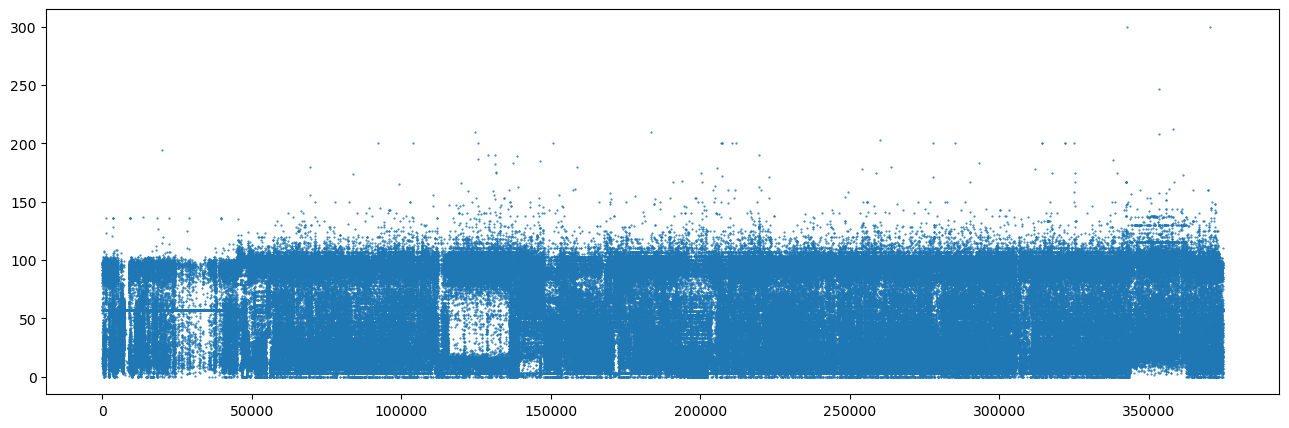

In [49]:
df_reset['macronutrient_columns'].plot(lw=0, marker=".", subplots=True, layout=(-1, 2), figsize=(35, 5), markersize=1); 

Macronutrient columns should contains a max value of 100 so removing the outliers which are higher than 100 values. As a rounding error I am choosing the limit to 101.

In [50]:
entry_to_drop = df_reset['macronutrient_columns'].gt(101)
df_reset = df_reset[~entry_to_drop]

After removing ouliers here again checking by plotting.

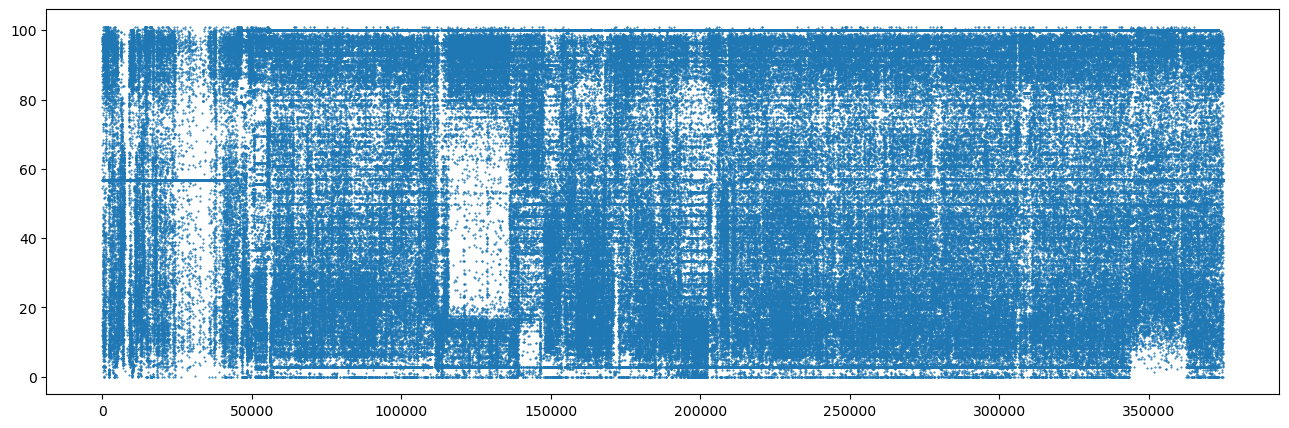

In [51]:
df_reset['macronutrient_columns'].plot(lw=0, marker=".", subplots=True, layout=(-1, 2), figsize=(35, 5), markersize=1); 

Here, in the plot, there are no data out of range (which is 100) for macronutrients. The data is cleaned for this case.

4 b) The column "energy_per_hundred" measures the energy content in kJ. Analyzing its relationship with the column "energy_kcal_per_hundred".

Energy_pre_hundred which is given in kJ and energy_kcal_pre_hundred which is in kcal, should has a linear relationship mathamaticaly. I am trying to use this relation to explore the inconsistency in these columns. First I am calculating the factor and see how the factor are varying for each case by ploting. Later I will remove the data which are not  close to the mathamatical factor (4.184) by taking some margin (0.1). It can be different depdent on the choice of correctness. 

In [52]:
df_reset['factor'] = df_reset['energy_per_hundred'] / df_reset['energy_kcal_per_hundred'] 

C:\Users\Guest\AppData\Local\Temp\ipykernel_23928\4070126728.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_reset['factor'] = df_reset['energy_per_hundred'] / df_reset['energy_kcal_per_hundred']


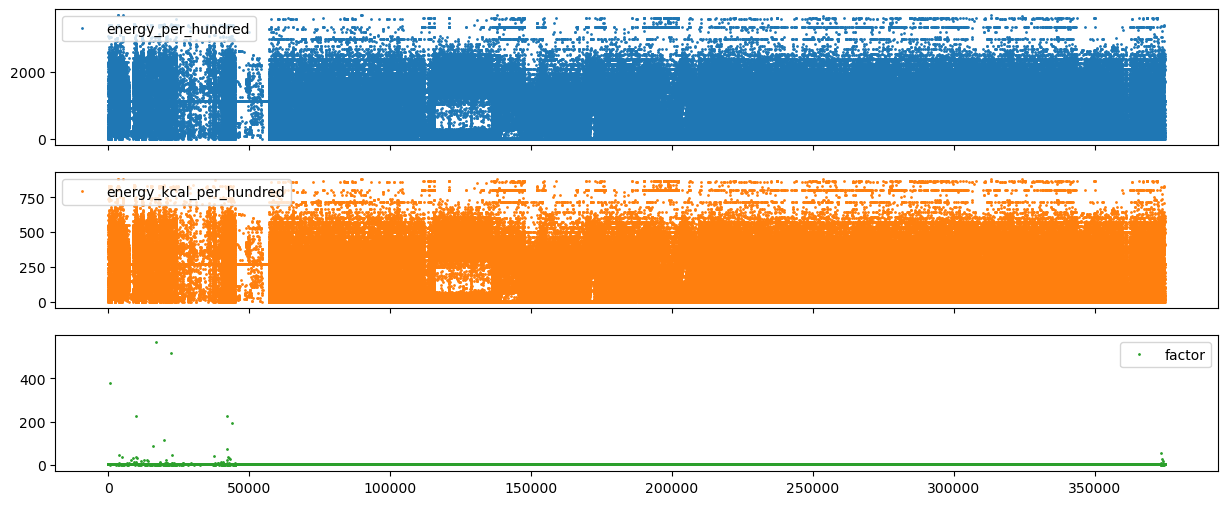

In [53]:
df_reset[['energy_per_hundred', 'energy_kcal_per_hundred', 'factor']].plot(lw=0, marker=".", subplots=True, figsize=(15, 6), markersize=2);
plt.show()

As we can see from the above plot that the factor is not constant and there are many outliers.

In [54]:
entries_to_drop = (abs(df_reset['factor'] - 4.184)).gt(0.1)
df_reset = df_reset[~entries_to_drop]

In [55]:
df_reset['factor'].describe()

count    330759.000000
mean          4.184140
std           0.009314
min           4.084906
25%           4.183981
50%           4.184000
75%           4.184007
max           4.283333
Name: factor, dtype: float64

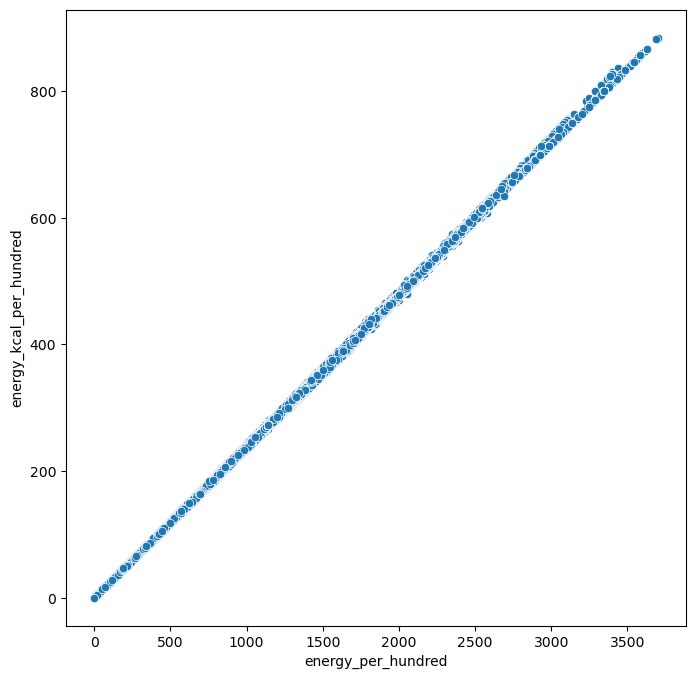

In [56]:

features = ["energy_per_hundred", "energy_kcal_per_hundred"]
plt.figure(figsize=(8, 8))
sns.scatterplot(x="energy_per_hundred", y="energy_kcal_per_hundred", data=df_reset)
plt.show()

<Figure size 800x800 with 0 Axes>

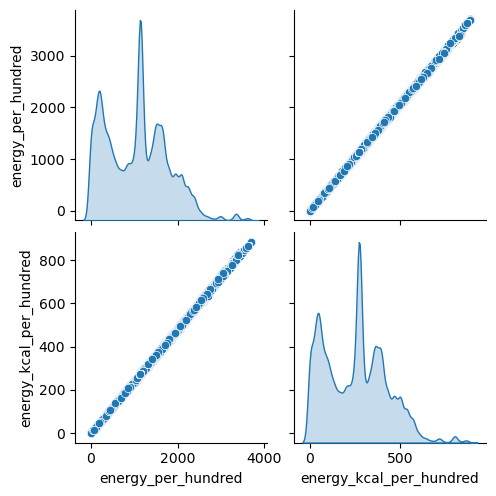

In [57]:
plt.figure(figsize=(8, 8))
sns.pairplot(df_reset[["energy_per_hundred", "energy_kcal_per_hundred"]], diag_kind='kde')
plt.show()

Observation: Now, the graph is showing a linear relationship which it is supposed to be in ideal case. I used the scatter plot and pair plot to visulaize the relationship here. 

4 c) Each of the four macronutrients has a specific energy content. Calculating the energy provided by these four macronutrients and then comparing this to the "energy_per_hundred"-column.

In this subtask, the idea is to use the energy values to identify the inconsistency in the data. We have a column name energy_pre_hundered and we will calculate the energy_pre_hundered by using macronutrients energy. The difference should be zero in ideal case. So I will calculate the difference and remove the values if the difference is out of the threshold values (which I am taking here is 10)

Energy comparison:
        energy_per_hundred  calculated_energy  energy_difference
0              1500.000000        1500.944971          -0.944971
1              1010.000000        1014.500000          -4.500000
2              1358.300000        1689.774971        -331.474971
3              1679.000000        1677.500000           1.500000
4              2470.000000        2465.000000           5.000000
...                    ...                ...                ...
374878          858.000000         866.504971          -8.504971
374879         1139.512786        1194.860286         -55.347500
374881         2418.000000        2311.904971         106.095029
374882         1139.512786        1194.860286         -55.347500
374883         1139.512786        1194.860286         -55.347500

[345035 rows x 3 columns]


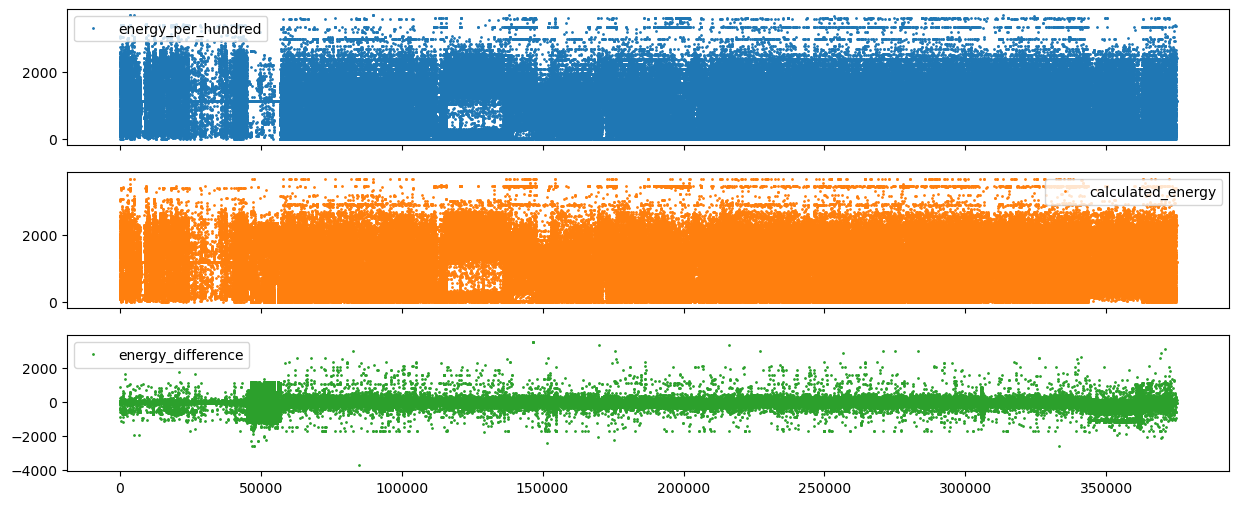

In [58]:
energy_content = {
    'fat': 37,      
    'protein': 17, 
    'carbohydrates': 17,   
    'fiber': 8      
}

df_reset['calculated_energy'] = (
    df_reset['fat_per_hundred'] * energy_content['fat'] +
    df_reset['protein_per_hundred'] * energy_content['protein'] +
    df_reset['carbohydrates_per_hundred'] * energy_content['carbohydrates'] +
    df_reset['fiber_per_hundred'] * energy_content['fiber']
)

df_reset['energy_difference'] = df_reset['energy_per_hundred'] - df_reset['calculated_energy']

print("Energy comparison:")
print(df_reset[['energy_per_hundred', 'calculated_energy', 'energy_difference']])
df_reset[['energy_per_hundred', 'calculated_energy', 'energy_difference']].plot(lw=0, marker=".", subplots=True, figsize=(15, 6), markersize=2);
plt.show()


In [59]:
df_reset['energy_difference'].describe()

count    345035.000000
mean        -32.991348
std         204.067899
min       -3700.000000
25%         -55.347500
50%         -23.404971
75%           1.660000
max        3532.995029
Name: energy_difference, dtype: float64

As it can be seen from the above plot, the calculated energy is higher than the energy per hundred in many datapoints. The calculated energy should always be less than the energy per hundered so I am removing the outliers which has the difference in negetive. As in the _per_hundered_ columns, earlier I select the rounding error to 101 so to include that into this calculated energy, I can account of max error values. The maximum error which should be allowed here is maximum of energy amoung the fat, protein,  carbohydrates or fiber for 1g. Therefore, I am considering the limit to 37 (for fat, which has max energy/g)

Finaly, I am removing the data which has the enegy difference less than -37

In [60]:
entries_to_drop = (df_reset['energy_difference']).le(-37)
df_reset = df_reset[~entries_to_drop]

Checking the data after cleaning by plotting.

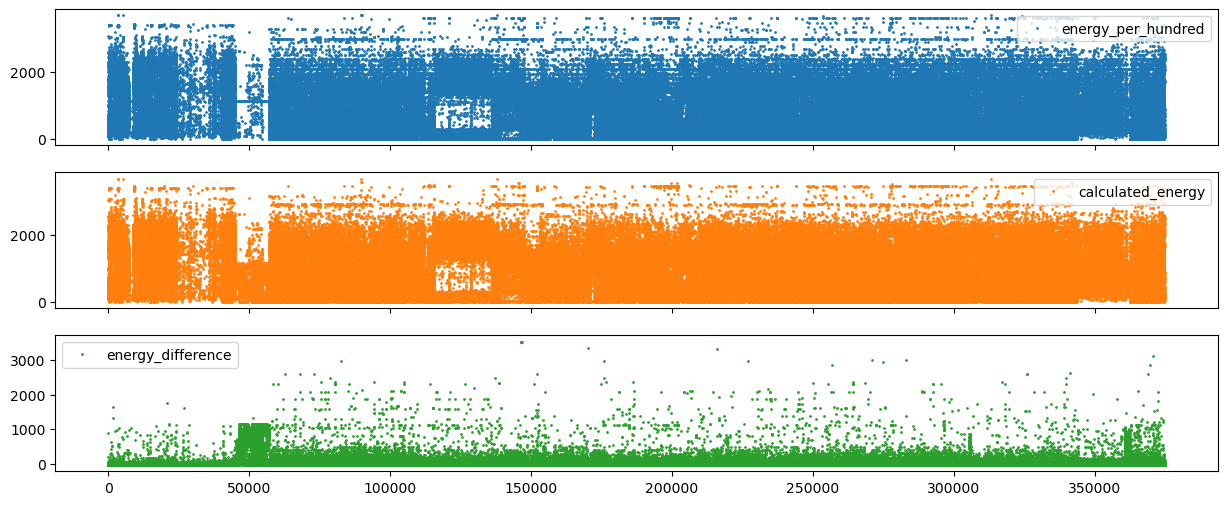

In [61]:
df_reset[['energy_per_hundred', 'calculated_energy', 'energy_difference']].plot(lw=0, marker=".", subplots=True, figsize=(15, 6), markersize=2);
plt.show()

As per the above plot, the energy difference is above the threshold value.

**5.Picking a few variables from the per_hundred list and Checking if outliers present than addressing those outliers.**

In [62]:
df_reset[per_hundred_cols].describe()

,calcium_per_hundred,carbohydrates_per_hundred,cholesterol_per_hundred,energy_kcal_per_hundred,energy_per_hundred,fat_per_hundred,fatty_acids_total_saturated_per_hundred,fatty_acids_total_trans_per_hundred,fiber_per_hundred,iron_per_hundred,...,saturated_fat_per_hundred,sodium_per_hundred,sugars_added_per_hundred,sugars_per_hundred,vitamin_a_iu_per_hundred,vitamin_b1_thiamin_per_hundred,vitamin_b2_riboflavin_per_hundred,vitamin_b3_niacin_per_hundred,vitamin_c_ascorbic_acid_per_hundred,vitamin_d_d2_d3_international_units_per_hundred
count,213665.000000,213665.000000,213665.000000,213665.000000,213665.000000,213665.000000,213665.000000,213665.000000,213665.000000,213665.000000,...,213665.000000,213665.000000,213665.000000,213665.000000,213665.000000,213665.000000,213665.000000,213665.000000,213665.000000,213665.000000
mean,98.975022,24.444783,54.030794,220.698786,923.326264,9.489145,4.327806,0.033739,1.662934,1.784962,...,5.916923,0.880623,23.443162,13.209645,495.206517,0.925756,1.637186,9.866460,15.353691,13.826507
std,438.418520,25.953814,1141.606497,173.073565,723.674621,13.633999,5.750577,0.382530,2.081821,103.652505,...,2.364298,3.270262,6.684366,17.629377,1745.886235,3.155714,0.814372,11.627836,281.781562,26.915654
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,7.000000,4.130000,0.000000,62.000000,259.410000,0.000000,0.000000,0.000000,0.000000,0.000000,...,5.904191,0.050000,23.993521,1.270000,0.000000,0.925326,1.680103,9.846486,0.000000,14.186515
50%,71.000000,13.090000,20.000000,200.000000,836.800000,3.170000,3.570000,0.000000,1.300000,0.000000,...,5.904191,0.320000,23.993521,5.600000,494.236708,0.925326,1.680103,9.846486,15.704688,14.186515
75%,116.647405,42.110000,58.981358,357.000000,1493.690000,15.000000,4.943331,0.034861,2.925621,1.090000,...,5.904191,0.770000,23.993521,16.992009,494.236708,0.925326,1.680103,9.846486,15.704688,14.186515
max,93750.000000,100.000000,100000.000000,885.000000,3700.000000,100.000000,93.330000,48.750000,79.000000,26666.670000,...,99.400000,100.000000,100.000000,100.000000,333333.000000,1111.000000,172.410000,4146.340000,71428.600000,5000.000000


There are a lots of coloumns which might have outliers by looking at their 75% and max values, but as per asked in project picking some of them. 

In [63]:
few_per_hundred_cols = per_hundred_cols[1:10]
row = list(range(0, len(few_per_hundred_cols)))

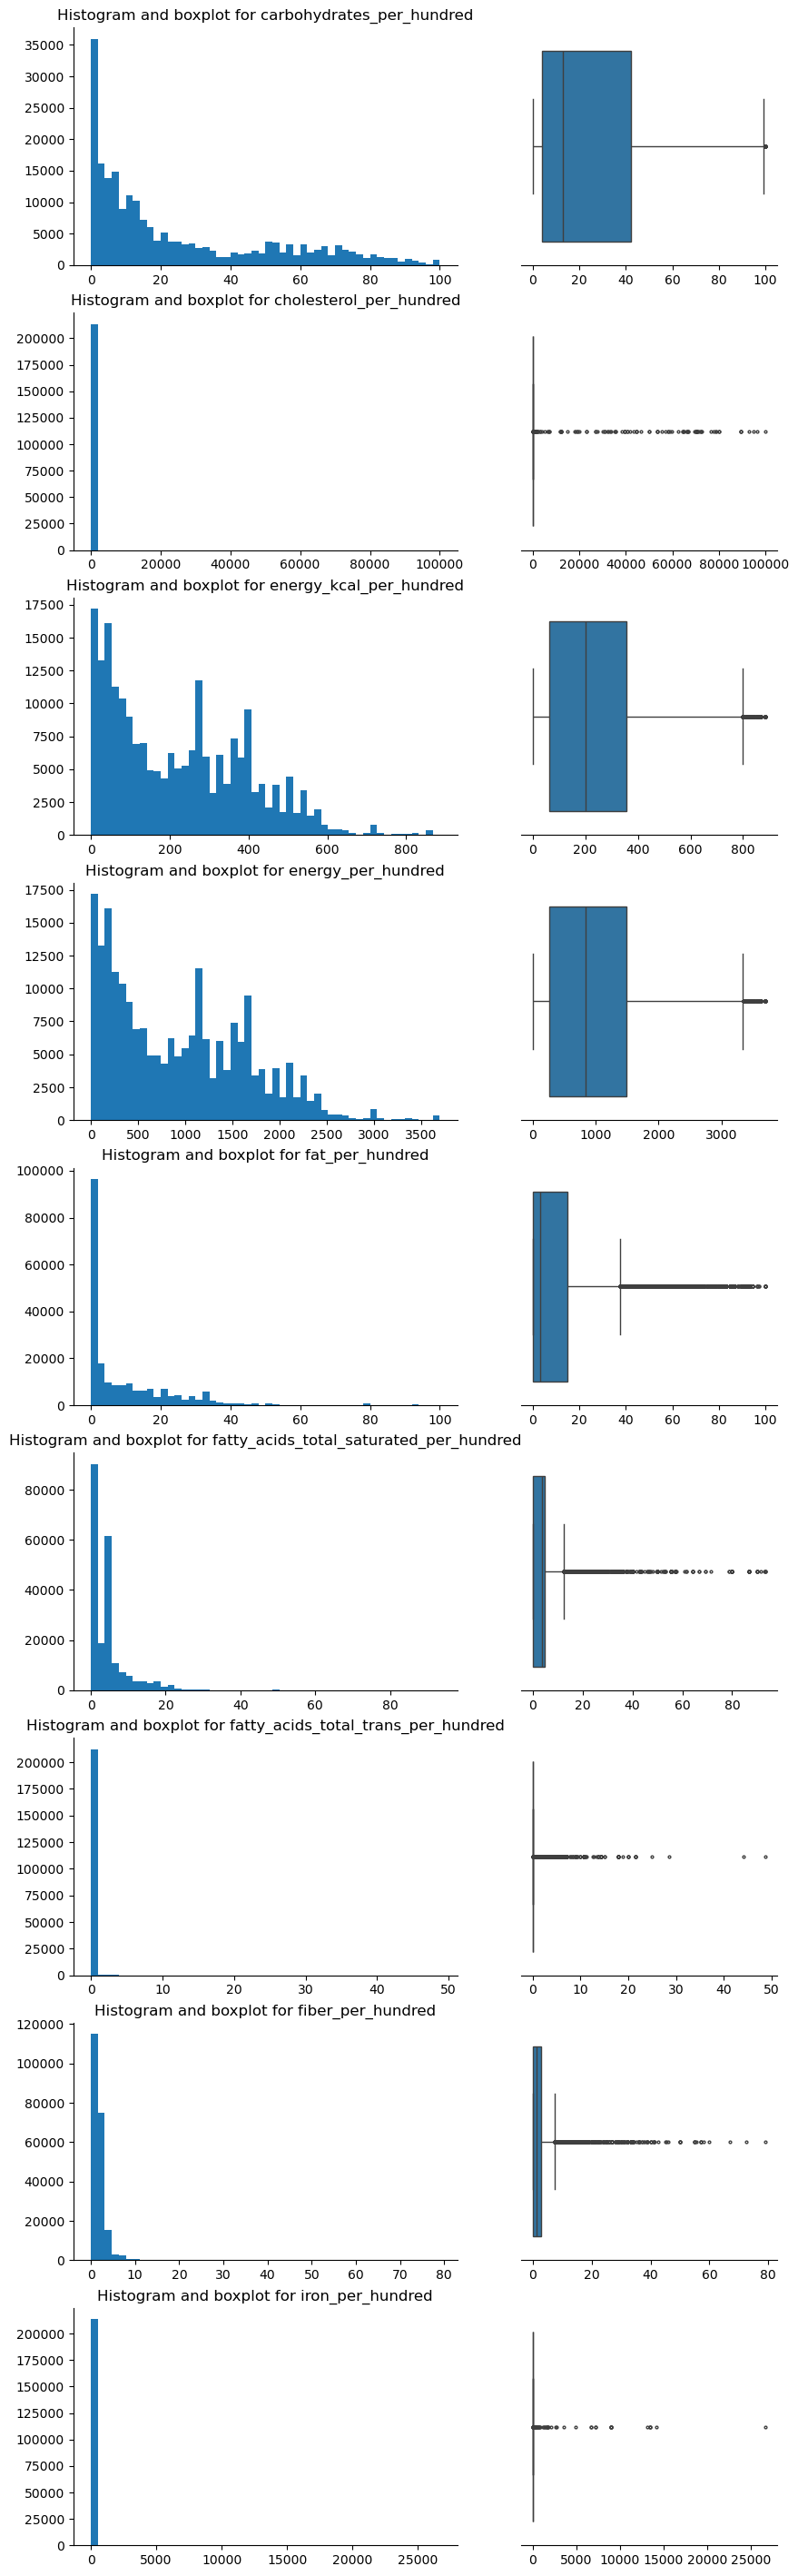

In [64]:
fig, axes = plt.subplots(len(few_per_hundred_cols),2,gridspec_kw={"width_ratios": (0.6, 0.4)} , figsize=(10,len(few_per_hundred_cols)*4)
)

for (feat, plot_col) in zip(few_per_hundred_cols, row):
    axes[plot_col,0].hist(df_reset[feat], bins=50)
    axes[plot_col,0].set_title("Histogram and boxplot for {}".format(feat))
    sns.despine(ax=axes[ plot_col,0])
    sns.boxplot(data=df_reset[feat], orient="h", ax=axes[plot_col,1], fliersize=2)
    axes[plot_col,1].set(yticks=[])
    sns.despine(ax=axes[plot_col,1], left=True)

for ax in axes.flatten():
    ax.set_xlabel("")

plt.show()

From the Above plots, I am picking some selected (plot no: 2,6,7,8 and 9) to plot the histogram with log scale and remove the oulier in next code by using zscore with threshold =3

In [65]:
selected_few_hundred_cols = [few_per_hundred_cols[1], few_per_hundred_cols[5], few_per_hundred_cols[6], few_per_hundred_cols[7], few_per_hundred_cols[8]]

threshold = 3
z1 = np.abs(stats.zscore(df_reset[few_per_hundred_cols[1]]))
df_reset = df_reset[z1 <= threshold]
z5 = np.abs(stats.zscore(df_reset[few_per_hundred_cols[5]]))
df_reset = df_reset[z5 <= threshold]
z6 = np.abs(stats.zscore(df_reset[few_per_hundred_cols[6]]))
df_reset = df_reset[z6 <= threshold]
z7 = np.abs(stats.zscore(df_reset[few_per_hundred_cols[7]]))
df_reset = df_reset[z7 <= threshold]
z8 = np.abs(stats.zscore(df_reset[few_per_hundred_cols[8]]))
df_reset = df_reset[z8 <= threshold]

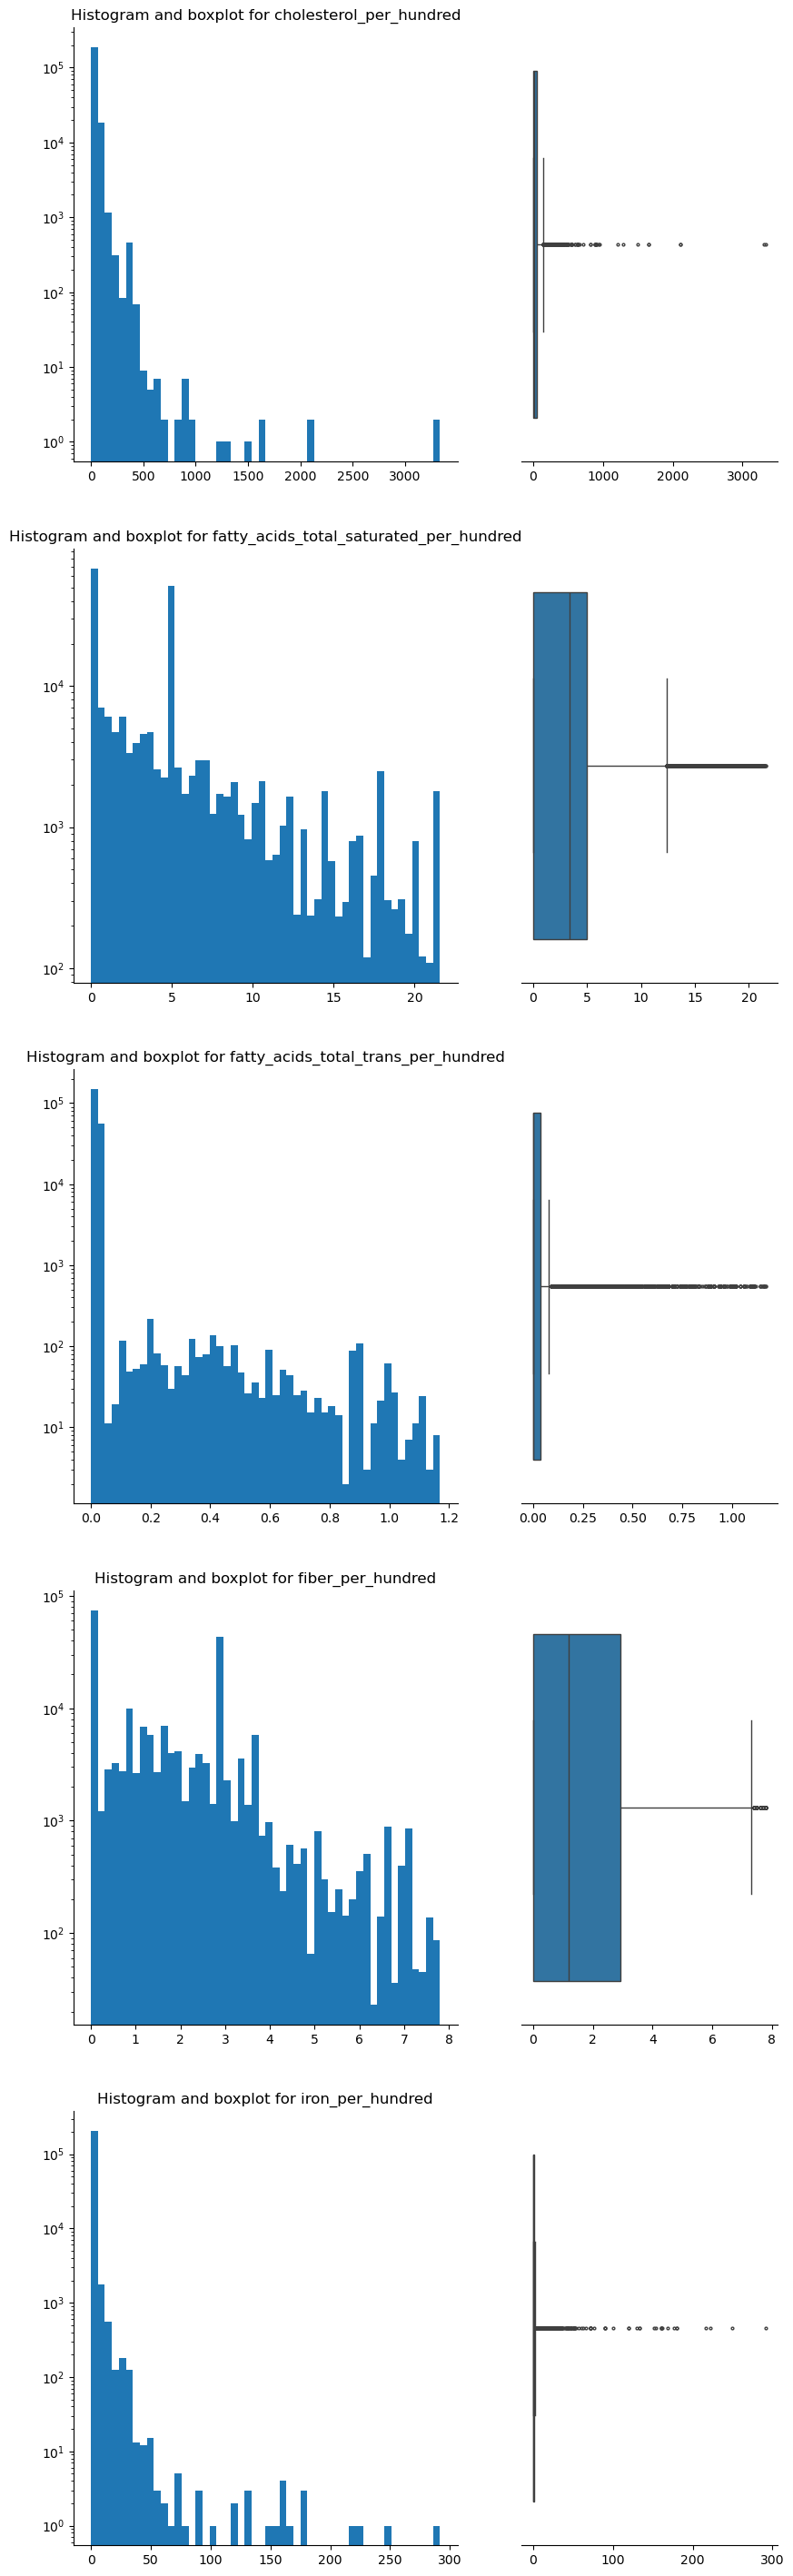

In [66]:

fig, axes = plt.subplots(len(selected_few_hundred_cols),2,gridspec_kw={"width_ratios": (0.6, 0.4)} , figsize=(10,len(few_per_hundred_cols)*4)
)

for (feat, plot_col) in zip(selected_few_hundred_cols, row):
    axes[plot_col,0].hist(df_reset[feat], bins=50)
    axes[plot_col,0].set_title("Histogram and boxplot for {}".format(feat))
    axes[plot_col, 0].set_yscale("log")
    sns.despine(ax=axes[ plot_col,0])
    sns.boxplot(data=df_reset[feat], orient="h", ax=axes[plot_col,1], fliersize=2)
    axes[plot_col,1].set(yticks=[])
    sns.despine(ax=axes[plot_col,1], left=True)
    

for ax in axes.flatten():
    ax.set_xlabel("")


plt.show()

However, after applying the zscore, there are still outliers in some of the columns (cholesterol_pre_hundred and iron_pre_hundred). I am removing them by setting a threshold values from the above graphs. Here I am using removing for cholesterol_pre_hundred and iron_pre_hundred.  I am picking the the threshold cholesterol_pre_hundred is 1000 and for iron_pre_hundred is 80.

In [67]:
#In this , there are outliers after 4000.
filter_cholestrol = df_reset[selected_few_hundred_cols[0]] > 1000
outliers_manual = df_reset.loc[filter_cholestrol, selected_few_hundred_cols[0]]
# removing the oulier
df_keep = df_reset.loc[~filter_cholestrol]
# creating a copy to the same dataframe for easy access
df_reset = df_keep.copy()

In [68]:
#In this , there are outliers after 4000.
filter_cholestrol = df_reset[selected_few_hundred_cols[4]] > 80
outliers_manual = df_reset.loc[filter_cholestrol, selected_few_hundred_cols[4]]
# removing the oulier
df_keep = df_reset.loc[~filter_cholestrol]
# creating a copy to the same dataframe for easy access
df_reset = df_keep.copy()

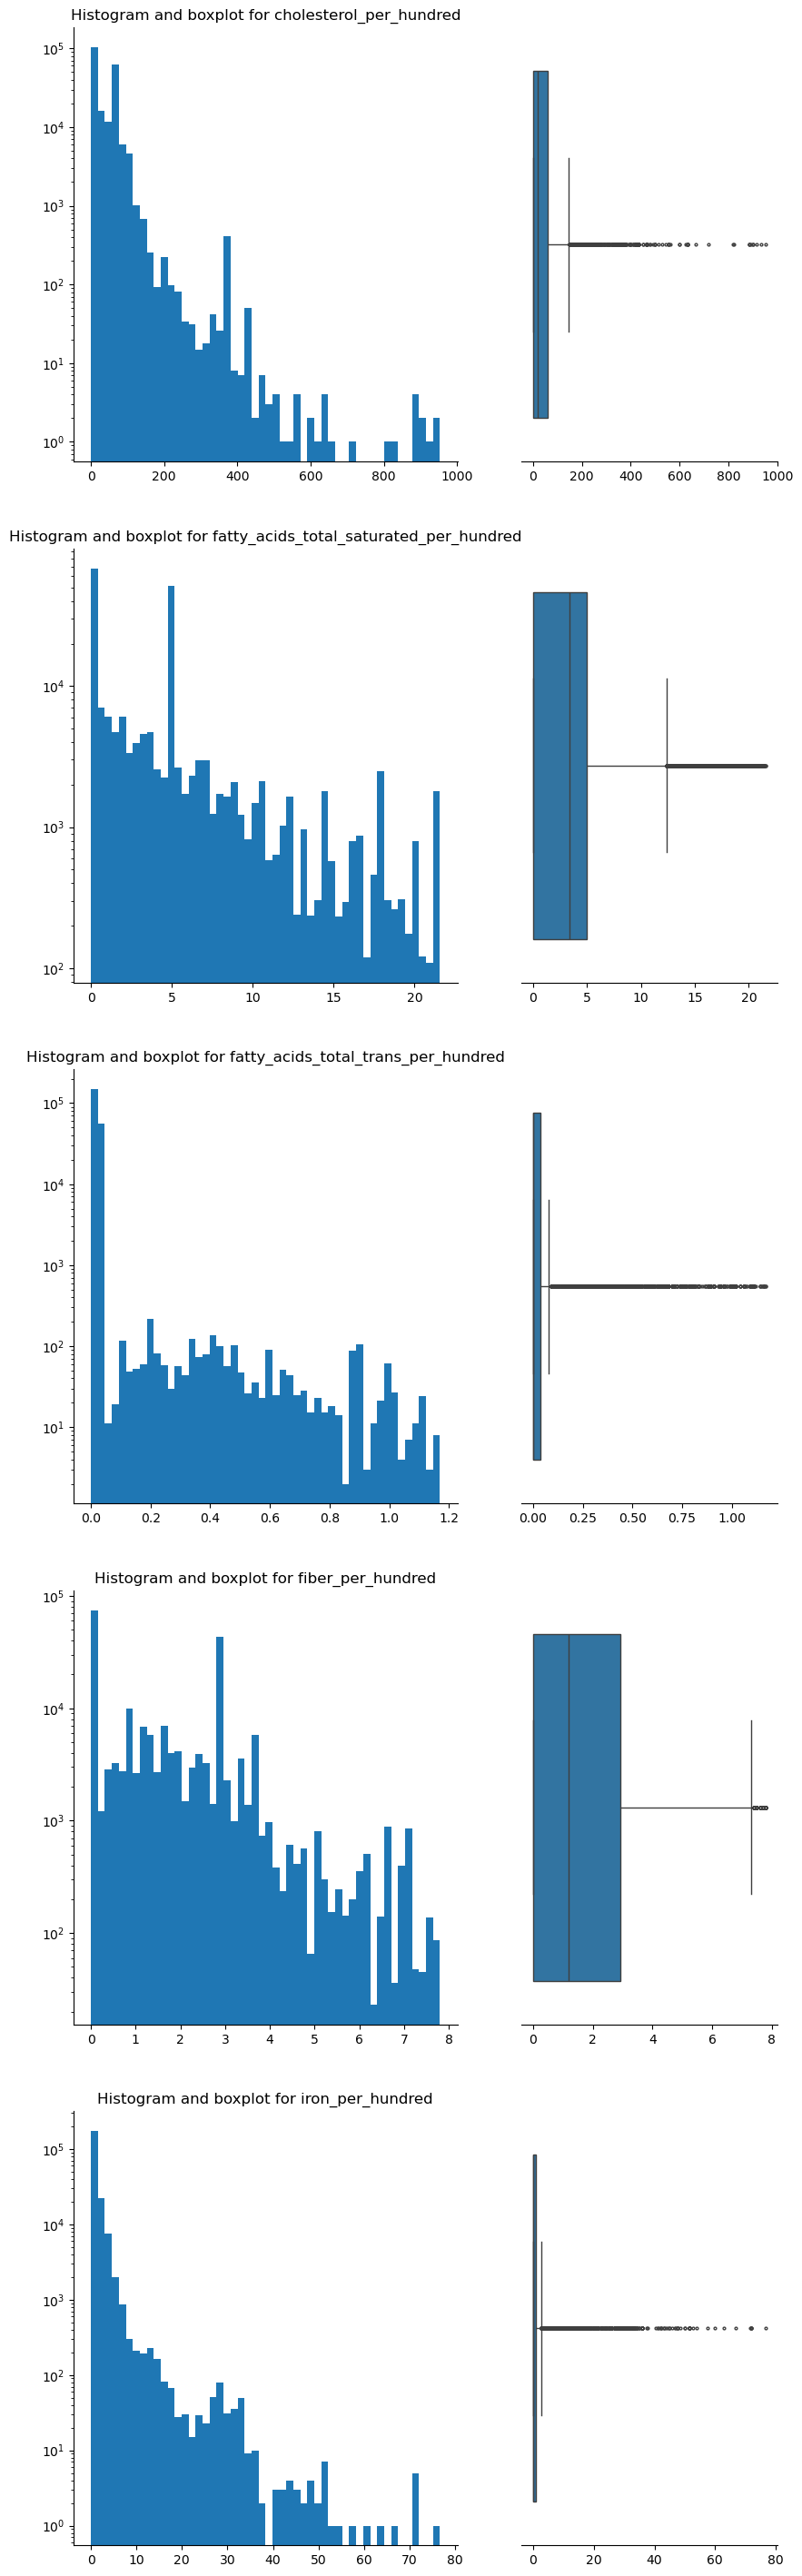

In [69]:
fig, axes = plt.subplots(len(selected_few_hundred_cols),2,gridspec_kw={"width_ratios": (0.6, 0.4)} , figsize=(10,len(few_per_hundred_cols)*4)
)

for (feat, plot_col) in zip(selected_few_hundred_cols, row):
    axes[plot_col,0].hist(df_reset[feat], bins=50)
    axes[plot_col,0].set_title("Histogram and boxplot for {}".format(feat))
    axes[plot_col, 0].set_yscale("log")
    sns.despine(ax=axes[ plot_col,0])
    sns.boxplot(data=df_reset[feat], orient="h", ax=axes[plot_col,1], fliersize=2)
    axes[plot_col,1].set(yticks=[])
    sns.despine(ax=axes[plot_col,1], left=True)
    

for ax in axes.flatten():
    ax.set_xlabel("")


plt.show()

Now, From the above plots, it is confirmed that the outliers are removed from the selected data columns.

# Task D. EDA: Text data


First reset the index of the dataframe.

In [70]:
# there are some rows that have ingredients missing,removing those rows
df_reset =df_reset[df_reset['ingredients_en'] != 'ingredients_missing']
df_reset = df_reset.reset_index(drop=True)

In [71]:
# extracting the ingredients_en column just to see the ingredients
df_ingredients_en = df_reset["ingredients_en"]
df_ingredients_en

0         Superior quality durum wheat Pasta\r\n\r\nIngr...
1                      Bio Milk (Switzerland), kitchen salt
2                                              cocoa powder
3         Sugar, whole milk powder, cocoa butter, cocoa ...
4                                         durum wheat flour
                                ...                        
194162    water, canola oil*, stabilizers (carrageenan, ...
194163    Cream (milk), mango puree concentrate (36%), t...
194164    sugar, almonds 27%, cocoa butter, cocoa mass, ...
194165    Water, Aloe vera gel powder 12%, Sugar, Aloe v...
194166    cocoa mass, fat reduced cocoa, cocoa butter, d...
Name: ingredients_en, Length: 194167, dtype: object

In [72]:
# Picking 5 randome rows for the ingredients_en
number_of_rows = 5
random_state = np.random.randint(0, df_reset.shape[0]-number_of_rows)
random_rows = df_reset.sample(n=number_of_rows, random_state=random_state)

for i, row in random_rows.iterrows():
    print(f"Product name: {row['product_name_en']} \nIngredients list:  {row['ingredients_en']}")

Product name: FRENCH BREAD 
Ingredients list:  ENRICHED UNBLEACHED WHEAT FLOUR (WHEAT FLOUR, NIACIN, IRON AS FERROUS SULFATE, THIAMINE MONONITRATE, ENZYME, RIBOFLAVIN, FOLIC ACID), WATER, YEAST, CONTAINS LESS THAN 2% OF THE FOLLOWING: SALT, WHEAT GLUTEN, SUGAR, SOYBEAN OIL, MALTED BARLEY FLOUR, DEXTROSE, ASCORBIC ACID, ENZYME.
Product name: Swiss Dream Zermatt 20 Napolitains pralinés 
Ingredients list:  sugar, cocoa mass, cocoa butter, whole milk powder, hazelnuts 6%, skimmed milk powder, cream milk powder, lactose, whey powder, concentrated butter, emulsifier (soya lecithin), barley malt extract, vanilla extract. (Cocoa: 25% min in milk recipe, 50% in dark). May contain other shell fruit, peanuts.
Product name: EGG WHITES 
Ingredients list:  100% LIQUID EGG WHITES.
Product name: SNICKERDOODLE SMART LITTLE COOKIE, SNICKERDOODLE 
Ingredients list:  [NON-GMO] ORGANIC CANE SUGAR, PALM OIL, WHITE RICE FLOUR, BROWN RICE FLOUR, INVERT SYRUP, WATER, RICE SYRUP, GRAPE JUICE, VEGETABLE FIBERS (

Some issues are identified such as: 
1. Inconsistent use of commas and spaces at some places.
2. Some ingredients are separated by commas, while others might use different delimiters.
3. Some ingredients are used many times and has so many redundant words.

Cleaning strategy:
1. A large list of redundant phrases is being removed from the ingredients to eliminate unnecessary terms like "organic," "natural," "processed", and "fortified" etc. that don’t contribute to meaningful analysis.
2. Text normalization (such as Lemmatization) is done to ensures consistency by reducing variations of words to their base form.
3. Various unwanted symbols, punctuation and inconsistent formatting such as extra spaces or percentages are being cleaned up to create a more consistent and usable ingredient list.
4. Duplicates are being removed so that each ingredients appear only once in cleaned list.

The above task is done by creating two seperate functions (_clean_ingredients()_ and _final_process()_). these two functions are called by a single function name _process_ingredients()_ which is applied on the ingredient columns.
So in the _process_ingredients()_ function, following things are happening:
1. First, _clean_ingredients()_ function is applied which task is to make lower case, lemmatization, remove unwanted sysmbols and punchuations and then remove the redundant pharases.
2. Stripping unnecessary commas and whitespace, converting the list into a set (to remove duplicates) and sorting the ingredients alphabetically.
3. Finaly, _final_process()_ function is being called to remove leading/trailing commas and spaces and removing duplicated consecutive words, and (and,) which was appeared because of sorting ( we found this issue in many ingredients ). However, it can be avoided to adjust this functionality in the main _process_ingredients()_ function, but I am keeping it to make them a seperate for final processing.


In [ ]:

redundant_phrases = [    
    r"\ballergen.*?nut are processed\b",
    r"\ball.*? agriculture\b",
    r"\ball.*?coloring\b",
    r"\ball agricultural ingredient.*?farming\b",
    r"\bflavor enhancer|flavouring|flavoring|flavor|flavour|minimum|envelope \b",  
    r"\bgastronomic.*? sauce cooked durum\b",    
    r"\bartificial\b",        
    r"\bnatural\b",            
    r"\benriched\b",           
    r"\bprocessed\b",                 
    r"\bcontain less than\b", 
    r"\bnonfat\b",             
    r"\breduced\b",            
    r"\bsugar-free\b",      
    r"\blow-fat\b",           
    r"\bwith\b",     
    r"\bbio\b",            
    r"\bsyrup|acidity corrector\b", 
    r"\b2%\s*or\s*less\b",        
    r"\bsodium-free\b",              
    r"\b2%\s*or\s*less\b",      
    r"\borganic\b",
    r"\bfortified\b",    
    r"\btrace\s*amount\b",          
    r"\bfiltered|superior quality\b", 
    r"\bcocoa: minimum.*?milk chocolate\b",
    r"\bmay contain.*? kernel\b",
    r"\bmay contain.*? nut\b",
    r"\bmay contain\b",
    r"\bingredient.*?mass balance\b",   
    r"\bcocoa content of chocolate.*?minimum\b",
    r"\bproduced:.*?processed\b",
    r"\bStore.*?temperature\b",    
    r"\b(natural|antioxidant|stabilizer|dye|acidifier|contains|based on|concentrate)\b",
    r"\bmalt extract supplemental food\b",
    r"\bof which\b",
    r"\bextract.*? least in\b",
    r"\bor.*? of\b",
    r"\bcontain the following\b"
]

def clean_ingredients(ingredients): 
    ingredients = ingredients.lower() 
    lemmatizer = WordNetLemmatizer()
    ingredients = " ".join(lemmatizer.lemmatize(word, pos='n') if word.isalpha() else word for word in re.split(r'(\W+)', ingredients))
      # to make all words singular
    ingredients = re.sub(r'\s*and/or\s*', ' ', ingredients)
    ingredients = re.sub(r'and / or', ',', ingredients)
    ingredients = re.sub(r'\s*,\s*', ',', ingredients)
    ingredients = re.sub(r'\(.*?\)', '', ingredients)
    ingredients = re.sub(r'\bB(\d)\b', r'B\1', ingredients)
    ingredients = re.sub(r'\bE(\d)\b', r'E\1', ingredients)       
    ingredients = re.sub(r'[.]', ',', ingredients)    
    ingredients = re.sub(r'[)]', '', ingredients) 
    ingredients = re.sub(r'[(]', '', ingredients)
    ingredients = re.sub(r'[#]', '', ingredients)
    ingredients = re.sub(r'[:]', '', ingredients)
    ingredients = re.sub(r'[;]', '', ingredients)
    ingredients = re.sub(r'\[', '', ingredients)
    ingredients = re.sub(r'\]', '', ingredients)
    ingredients = re.sub(r'\}', '', ingredients)
    ingredients = re.sub(r'\{', '', ingredients)
    ingredients = re.sub(r'[*]', '', ingredients)
    ingredients = re.sub(r'[-]', '', ingredients)    
    ingredients = re.sub(r'\[.*?\]', '', ingredients)
    ingredients = re.sub(r'\(\d+(\.\d+)?%\)', '', ingredients)
    ingredients = re.sub(r'(?!\bb\d+\b)\d+%?', '', ingredients)      
    ingredients = re.sub(r'%','', ingredients)    
    ingredients = re.sub(r'(\w)\s+,', r'\1,', ingredients)    
    ingredients = re.sub(r'\s+', ' ', ingredients)
    ingredients = re.sub(r'\d+%?\s*of the total weight', '', ingredients)
    ingredients = re.sub(r'may contain traces of', ',', ingredients)

    for phrase in redundant_phrases:
        ingredients = re.sub(phrase, '', ingredients, flags=re.IGNORECASE)
    
    # final cleaning if any extra names are still there
    ingredients = re.sub(r'ingredient', ',', ingredients)
    ingredients = re.sub(r'trace of', ',', ingredients)    
    return ingredients



def final_process(ingredients):
    ingredients = re.sub(r'\s+,', ',', ingredients)  

    ingredients = re.sub(r'^[,]+', '', ingredients).strip()

    if ingredients.endswith('/'):
        ingredients = ingredients[:-1].strip()
  
    ingredients = re.sub(r'\b(\w+)(?=\s+\1\b)', '', ingredients).replace("  ", " ").strip() 
    ingredients = re.sub(r'^(?:and,\s*)+', '', ingredients)
    return ingredients

def process_ingredients(row):    
    ingredients = clean_ingredients(row)   
    ingredients = ingredients.strip(',').strip()  
    ingredients_list = list(set(ingredients.split(',')))
    ingredients_list.sort() 
    ingredients_list = [re.sub(r'[,.()]', '', ingredient).strip() for ingredient in ingredients_list]
    ingredients = ', '.join(ingredients_list)
    ingredients = final_process(ingredients)
    if ingredients.startswith('and,'):
        print(ingredients)
    return ingredients


df_reset['cleaned_ingredients'] = df_reset['ingredients_en'].apply(process_ingredients)

As asked in task to address some of the main issues. I tested the above code and export the csv file of ingredient list and check manually mostly but it was not efficient to go through all of them. 
I would like to mention that there might be still inconsistency left in the data. 
There can be many short way but i choose to do it from basics to learn each steps significantly, which I guess was the main idea behind this task.
I have also used the lemmatizer to make the words singular. I could have also used the stopwords to remove the unwanted words but then it was making all the words seperated by commas which was hard to recombined the relevant words together. 

In this code, I took bit of help from AI tool and Google to make the code clean and more efficient. 
However I understood everything which is written above.
I have used the regular expressions such as ( to make the below code clean/optimize, to remove unwanted lines of code  etc.) 


Printing data before and after cleaning to insure the cleaning process.

In [74]:
# Picking 5 randome rows for the ingredients_en for displaying the cleaned ingredients and the original ingredients all together
number_of_rows = 5
rows = df_reset.iloc[1:6]
for i, row in rows.iterrows():
    print(f"Before cleaning:\n{row['ingredients_en']} \nAfter cleaning:\n{row['cleaned_ingredients']}")
    print(f"-----------")

Before cleaning:
Bio Milk (Switzerland), kitchen salt 
After cleaning:
kitchen salt, milk
-----------
Before cleaning:
cocoa powder 
After cleaning:
cocoa powder
-----------
Before cleaning:
Sugar, whole milk powder, cocoa butter, cocoa mass, honey (3.0%), concentrated butter, almonds (1.6%), emulsifier (soy lecithin), egg white, flavoring.
Cocoa: 28% minimum in milk chocolate. 
After cleaning:
cocoa in milk chocolate, almond, cocoa butter, cocoa mass, concentrated butter, egg white, emulsifier, honey, sugar, whole milk powder
-----------
Before cleaning:
durum wheat flour 
After cleaning:
durum wheat flour
-----------
Before cleaning:
Honey 
After cleaning:
honey
-----------


**1. The product with the longest ingredients list, i.e. the largest number of ingredients.**

In [75]:
df_reset['ingredient_count'] = df_reset['cleaned_ingredients'].apply(lambda x: len(x.split(',')))
idx_max = df_reset['ingredient_count'].idxmax(axis=0)
print("Product name of the product with maximum number of ingredients")
print(df_reset["product_name_en"].iloc[idx_max])
print("list of ingredients_en")
print(df_reset["cleaned_ingredients"].iloc[idx_max])

Product name of the product with maximum number of ingredients
12 SLICE VARIETY CHEESECAKE, CHOCOLATE CHIP, RASPBERRY WHITE CHOCOLATE, FUDGE BROWNIE, BLUEBERRY SWIRL, VANILLA BEAN, CARAMEL TURTLE, CHOCOLATE, RASPBERRY SWIRL, NEW YORK STYLE, CHOCOLATE CHERRY, CHOCOLATE MARBLE, STRAWBERRY SWIRL
list of ingredients_en
color water, milk powder, agar, apocarotenal, baking powder sodium acid pyrophosphate, baking soda, beta carotene, blueberry, calcium carbonate, calcium carrageenan, calcium sulfate, cane sugar, caramel color, caramel spread milk, carob bean and guar gum, carrageenan, cellulose gum, cherry, cherry topping montmorency cherry, chocolate chip sugar, chocolate liquor, cinnamon, citric acid, citric acid powder, cocoa, cocoa butter, corn starch, cornstarch, cream canola oil, cream carrageenan, cream cheese cultured cream and milk, dextrose, dipotassium phosphate, disodium phosphate, egg, erythorbic acid, ethyl vanilla, evaporated milk, fd & c red & yellow, fd & c yellow &, fruit f

2.**The products with the shortest ingredients list, i.e. the fewest ingredients.**

In [76]:
df_reset['ingredient_count'] = df_reset['cleaned_ingredients'].apply(lambda x: len(x.split(',')))
df_reset_sorted = df_reset.sort_values(by='ingredient_count')
print("Products with the shortest ingredients list:")
print(df_reset_sorted[['product_name_en', 'cleaned_ingredients', 'ingredient_count']].head(5).to_markdown())


Products with the shortest ingredients list:
|        | product_name_en                     | cleaned_ingredients   |   ingredient_count |
|-------:|:------------------------------------|:----------------------|-------------------:|
| 105909 | 100% PURE ORANGE JUICE              | orange juice          |                  1 |
|  65119 | SWEET GREEN PEAS                    | green pea             |                  1 |
|  65118 | SWEET GREEN PEAS                    | green pea             |                  1 |
|  10400 | TILAPIA FILLETS                     | tilapia               |                  1 |
| 121773 | RITA RITZ, SAMBONG DRIED HERBAL TEA | sambong leaf dc       |                  1 |


Observation:
There are many products with few ingredients (lets say almost one ingredient). these are mostly ingredient based products like, fruit juice and vegitables etc. 
On the other side, products with more ingredients are mostly processed or mixed products like water, sugar, milk powder etc.


**3.Identifying the ingredients which are most frequent across all products.**

I am plotting bar plots for ingredient counts against the number of products.

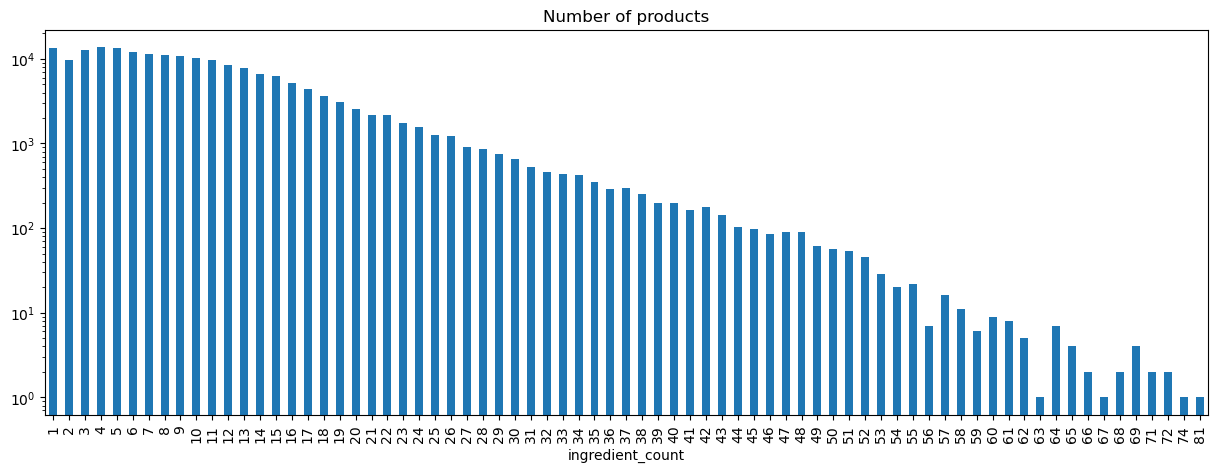

In [77]:
df_reset['ingredient_count'] = df_reset['cleaned_ingredients'].apply(lambda x: len(x.strip().split(',')))
#plot a bar graph to see the distribution of the ingredients
df_reset['ingredient_count'].value_counts().sort_index().plot(kind='bar', figsize=(15, 5), title="Number of products")
plt.yscale('log')

Here, I am plotting ingredient counts againt the number of products. It can be seen that mostly products have ingredient less than 20 and for higher ingredient counts, the number of products are less. Because mostly products are ingredient based, such as honey, milk, etc. 

In [78]:
#top 10 most frequent ingredients
ingredients_list = df_reset['cleaned_ingredients'].str.split(',').sum()
ingredients_count = Counter(ingredients_list)

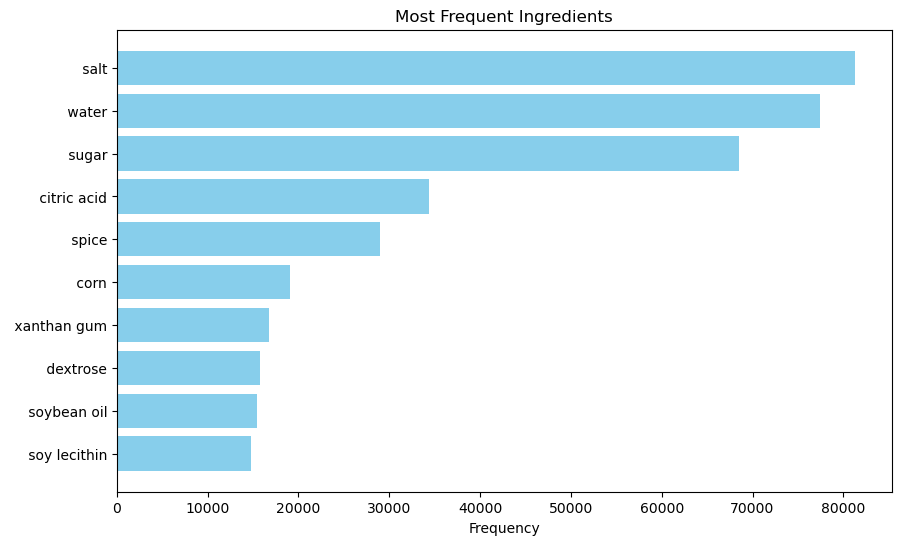

In [79]:
# Get the top 10 most frequents ingredients
top_ingredients = ingredients_count.most_common(10)
ingredients, counts = zip(*top_ingredients)

# Create the bar chart
plt.figure(figsize=(10, 6))
plt.barh(ingredients, counts, color='skyblue')
plt.xlabel('Frequency')
plt.title('Most Frequent Ingredients')
plt.gca().invert_yaxis()
plt.show()


Observation:
Salt, water and sugar are the most frequently used ingredients across all products, as they are essential in many products. Following them in frequency are citric acid, spices, and corn.


Printing the full ingredeint lists of some examples before and after text cleaning (as stated in the task)

In [80]:
# Picking 5 randome rows for the ingredients_en for displaying the cleaned ingredients and the original ingredients all together
number_of_rows = 5
rows = df_reset.iloc[1:6]
for i, row in rows.iterrows():
    print(f"Before cleaning:\n{row['ingredients_en']} \nAfter cleaning:\n{row['cleaned_ingredients']}")
    print(f"-----------")

Before cleaning:
Bio Milk (Switzerland), kitchen salt 
After cleaning:
kitchen salt, milk
-----------
Before cleaning:
cocoa powder 
After cleaning:
cocoa powder
-----------
Before cleaning:
Sugar, whole milk powder, cocoa butter, cocoa mass, honey (3.0%), concentrated butter, almonds (1.6%), emulsifier (soy lecithin), egg white, flavoring.
Cocoa: 28% minimum in milk chocolate. 
After cleaning:
cocoa in milk chocolate, almond, cocoa butter, cocoa mass, concentrated butter, egg white, emulsifier, honey, sugar, whole milk powder
-----------
Before cleaning:
durum wheat flour 
After cleaning:
durum wheat flour
-----------
Before cleaning:
Honey 
After cleaning:
honey
-----------


## Task E. EDA: Time-series data

**1. Investigation of the total number of items created each month at each hour.**

In [81]:
# getting familiar with the type of data in the column
df_reset["created_at"]

0         2016-06-01T11:42:22.908Z
1         2016-06-01T11:42:25.111Z
2         2016-06-01T11:42:29.472Z
3         2016-06-02T14:01:44.255Z
4         2016-06-02T14:01:51.499Z
                    ...           
194162    2021-09-24T07:26:19.082Z
194163    2021-09-24T08:09:48.668Z
194164    2021-09-27T09:01:14.855Z
194165    2021-09-28T08:35:16.798Z
194166    2021-10-04T14:22:10.685Z
Name: created_at, Length: 194167, dtype: object

Firstly, I will convert _created_at_ datafram to datetimes and then extract hour-month to check how many items are created at each hour in a month.

In [82]:
df_reset['created_at_datetime'] = pd.to_datetime(df_reset['created_at'])
df_reset['hour'] = df_reset['created_at_datetime'].dt.hour
df_reset['month'] = df_reset['created_at_datetime'].dt.month


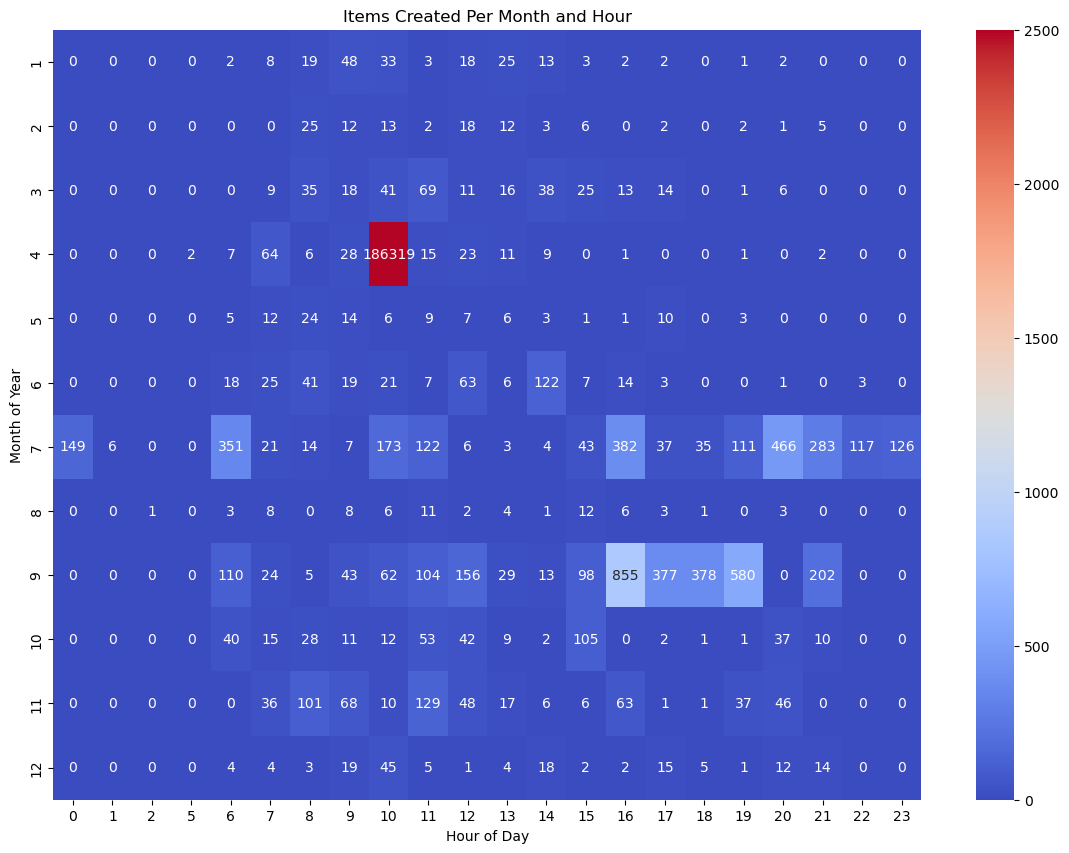

In [83]:
plt.figure(figsize=(14, 10)) 
heatmap_data = df_reset.pivot_table(index='month', columns='hour', aggfunc='size', fill_value=0) 
sns.heatmap(heatmap_data, annot=True, fmt="d", cmap='coolwarm',vmin=0, vmax=2500)
plt.title("Items Created Per Month and Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Month of Year")
plt.show()


Obsevation:
This graph tell how many items created at each hour in each month of year. 
Initially hour of the day items are created  very less except July (7th Month) and mostly items are created in the middle hour of the days.
The maximum items are created in an hour is in the 4th month of the year and 10th hour.
The most active or widely spread months are 7th, and 9th where mostly items are created at each hour except the starting hours of the day.

**2.Investigatin the evolution of the total number of items over time.**

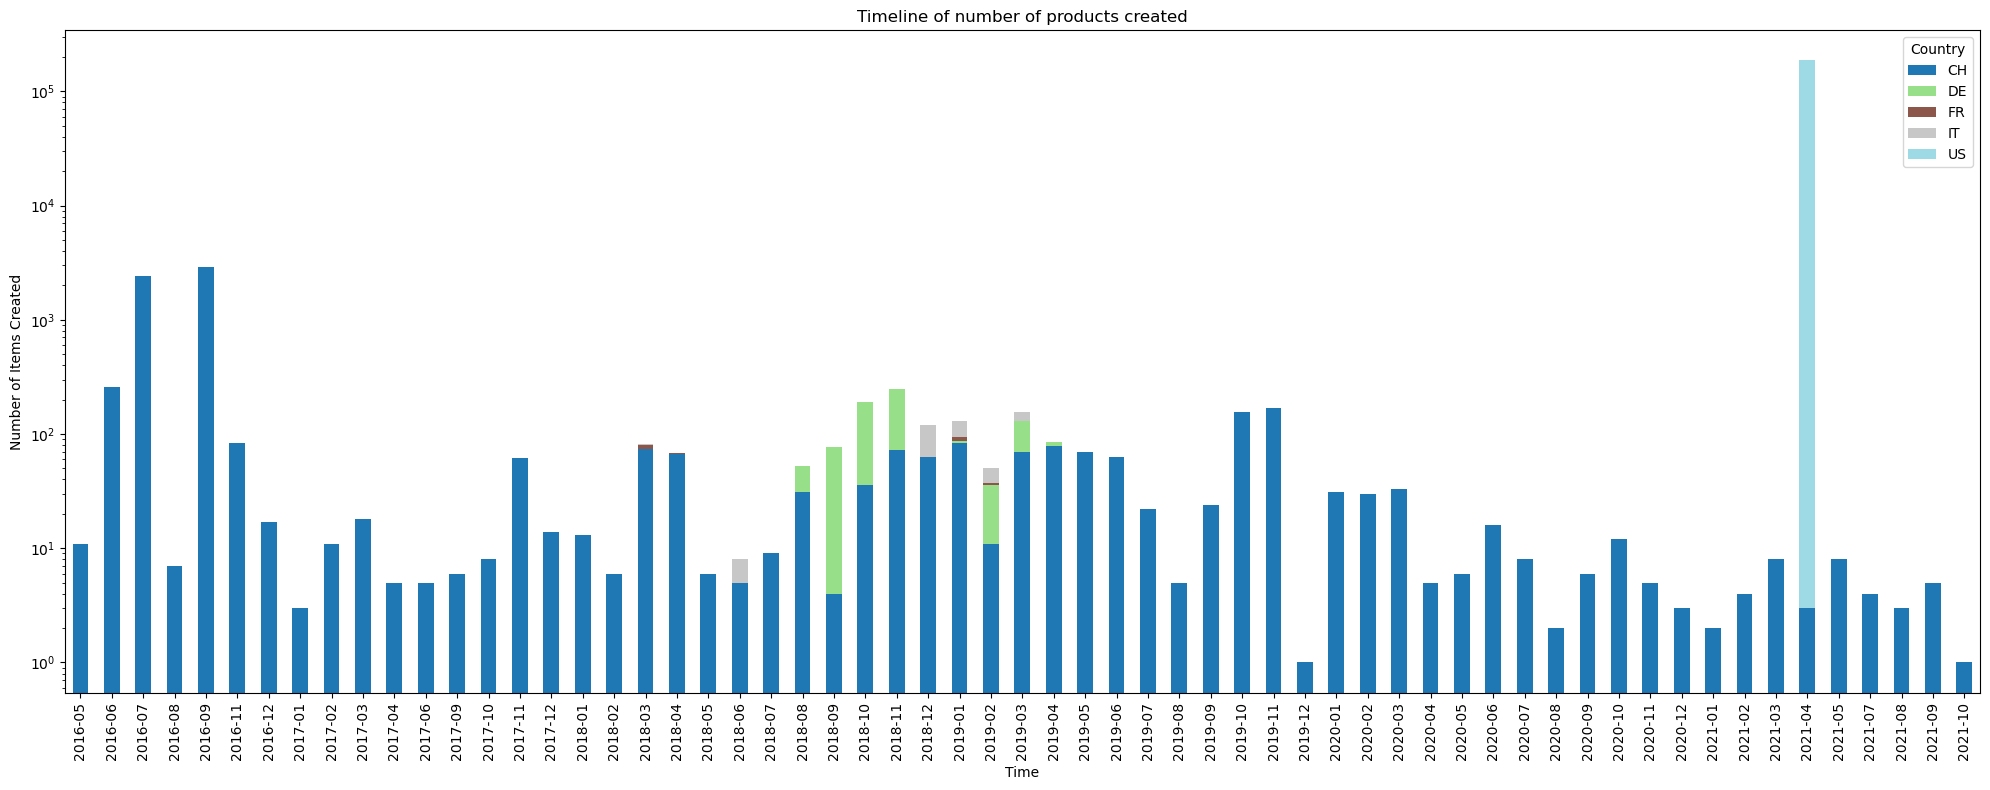

In [84]:
df_reset['year_month'] = df_reset['created_at_datetime'].dt.tz_localize(None).dt.to_period('M')
grouped = df_reset.groupby(['year_month', 'country']).size()
new_df = grouped.reset_index(name='count')
pivot_df = new_df.pivot(index='year_month', columns='country', values='count')

pivot_df.plot(kind='bar', stacked=True, figsize=(20, 8), colormap='tab20')
plt.title('Timeline of number of products created')
plt.xlabel('Time')
plt.ylabel('Number of Items Created')
plt.xticks(rotation=90)
plt.legend(title='Country', loc='upper right')
plt.yscale('log')
plt.tight_layout()
plt.show()

Observation:
Each bar in the plot showing stack the number of items created by each country each month.
Mostly items created by coutry CH through out the whole month range.
For the US, maximum no of items are created on 04-2021 only.
For the DE, FR, and IT, the numbers are very low and most for DE, the items are created at the end of 2018 and the begining of 2019.

## Task F. EDA: Correlation analysis

In [85]:
df_reset["energy_per_hundred"]

0         1500.0
1         1010.0
2         1524.0
3         2235.0
4         1490.0
           ...  
194162     756.0
194163    1202.0
194164    2406.0
194165     190.0
194166    2418.0
Name: energy_per_hundred, Length: 194167, dtype: float64

**1. Quantify the linear relationships between the energy_per_hundred and the per_hundred columns by analysing their correlation with each other..**

In [86]:
correlations = {}
for col in per_hundred_cols:
    corr_value = df_reset['energy_per_hundred'].corr(df_reset[col])
    correlations[col] = corr_value
for col, corr_value in correlations.items():
    print(f"Pearson Correlation between '{'energy_per_hundred'}' and '{col}': {corr_value:.3f}")

Pearson Correlation between 'energy_per_hundred' and 'calcium_per_hundred': 0.055
Pearson Correlation between 'energy_per_hundred' and 'carbohydrates_per_hundred': 0.631
Pearson Correlation between 'energy_per_hundred' and 'cholesterol_per_hundred': 0.088
Pearson Correlation between 'energy_per_hundred' and 'energy_kcal_per_hundred': 1.000
Pearson Correlation between 'energy_per_hundred' and 'energy_per_hundred': 1.000
Pearson Correlation between 'energy_per_hundred' and 'fat_per_hundred': 0.740
Pearson Correlation between 'energy_per_hundred' and 'fatty_acids_total_saturated_per_hundred': 0.503
Pearson Correlation between 'energy_per_hundred' and 'fatty_acids_total_trans_per_hundred': -0.016
Pearson Correlation between 'energy_per_hundred' and 'fiber_per_hundred': 0.088
Pearson Correlation between 'energy_per_hundred' and 'iron_per_hundred': 0.234
Pearson Correlation between 'energy_per_hundred' and 'monounsaturated_fatty_acids_per_hundred': 0.119
Pearson Correlation between 'energy_p

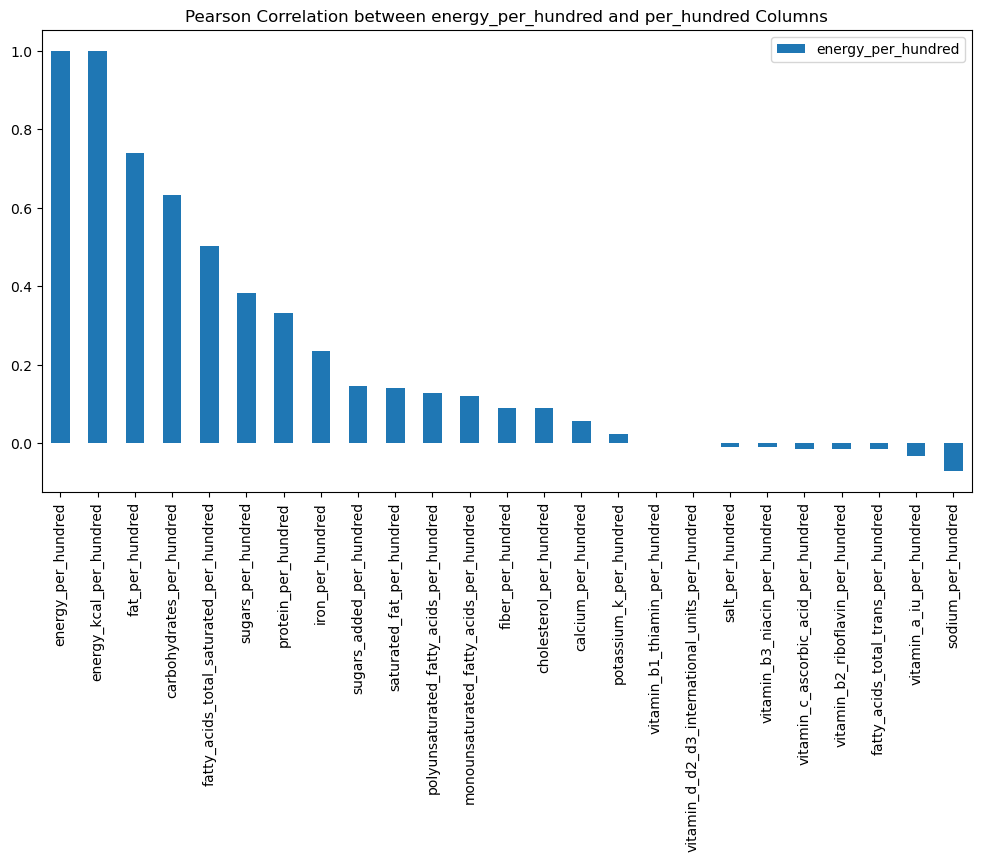

In [87]:
correlation_matrix = pd.DataFrame(correlations, index=['energy_per_hundred'])
correlation_matrix = correlation_matrix.T
correlation_matrix = correlation_matrix.sort_values(by='energy_per_hundred', ascending=False)
correlation_matrix.plot(kind='bar',figsize=(12, 6), title='Pearson Correlation between energy_per_hundred and per_hundred Columns')
plt.show()

As we can see that the values near to the zero are less correlated with energy_per_hundered. It can be clearly seen from the graph that energy_kcal and fat_per_hundered columns are more correlated.

2.**Based on the correlation coefficientsfound  in the previous task, picking the three most correlated and the three least correlated nutrients with the energy_per_hundred column.**

Selecting the most correlated columns with highest values and for the least correlated coloumns the value should be clsoe to zero.
Setting the threshold value close to zero to select the least correlated columns

In [114]:
correlation_matrix_transpose = correlation_matrix.T
Three_most_correlated = correlation_matrix_transpose.columns[1:4]
least_threshold = 0.0101
Three_least_correlated = correlation_matrix_transpose.columns[(correlation_matrix_transpose.abs() < least_threshold).all()]
print("Three most correlated columns:", Three_most_correlated)
print("Three least correlated columns:", Three_least_correlated)

correlation_list = Three_most_correlated.append(Three_least_correlated )

Three most correlated columns: Index(['energy_kcal_per_hundred', 'fat_per_hundred',
       'carbohydrates_per_hundred'],
      dtype='object')
Three least correlated columns: Index(['vitamin_b1_thiamin_per_hundred',
       'vitamin_d_d2_d3_international_units_per_hundred', 'salt_per_hundred'],
      dtype='object')


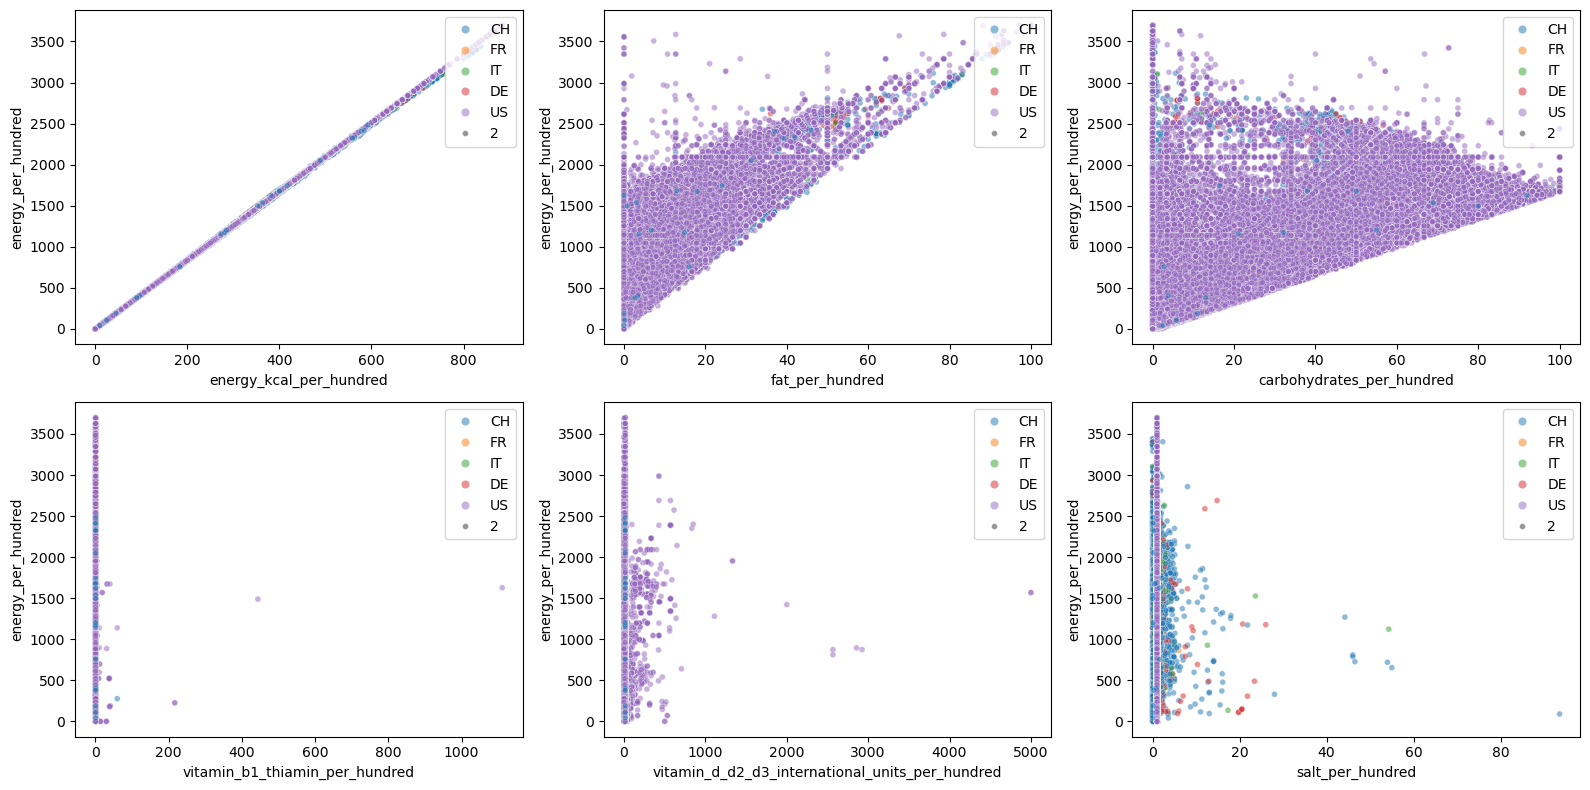

In [89]:
fig, axes = plt.subplots(ncols=3, nrows=2, figsize=(16, 8))

for col, ax in zip(correlation_list, axes.ravel()):
    sns.scatterplot(data=df_reset, x=col, y=df_reset["energy_per_hundred"], ax=ax, palette="tab10", size=2, alpha=0.5, hue= df_reset['country'])
    ax.legend(loc='upper right')
plt.tight_layout()

Observation:
In the most correlated plots, it can be seen that the data is nicely spread and has some linear relationship, while on the other hand, for the least correlated data, the data is not spread at all. The distribution of the data is directly related to the correlation of the data.  

**3.Testing of independence of two categorical variables statistically.**

In [90]:
df_reset['energy_category'] = pd.qcut(df_reset['energy_per_hundred'], q=3, labels=['Low Energy', 'Medium Energy', 'High Energy'])

contingency_table = pd.crosstab(df_reset['energy_category'], df_reset['country'])
chi2, p, dof, expected = chi2_contingency(contingency_table)

print(contingency_table)

print("\nChi-Square Test Results:")
print(f"Chi2 Value: {chi2}")
print(f"p-value: {p}")


country            CH   DE  FR  IT     US
energy_category                          
Low Energy       1352  100   1  23  63669
Medium Energy    2468   91  10  20  61796
High Energy      3358  325   5  92  60857

Chi-Square Test Results:
Chi2 Value: 1189.2143903114131
p-value: 2.0516745768864984e-251


The expected frequencies are checked and confirmed to be greater than 5, So the conditions of the chi2-test are met.

A higher Chi2 Value indicates a larger discrepancy between the observed and expected frequencies. That means the distribution of energy categories is not equally spread across the countries.

In [91]:
# Interpretation of the result:
if p < 0.05:
    print("\nThe p-value is less than 0.05, so we reject the null hypothesis.")
    print("There is a significant relationship between the two categorical variables.")
else:
    print("\nThe p-value is greater than 0.05, so we fail to reject the null hypothesis.")
    print("There is no significant relationship between the two categorical variables.")
    


The p-value is less than 0.05, so we reject the null hypothesis.
There is a significant relationship between the two categorical variables.


Checking if the level of energy in the product is associated with the country where the product is produced.

In [92]:
contingency_table

country,CH,DE,FR,IT,US
energy_category,,,,,
Low Energy,1352,100,1,23,63669
Medium Energy,2468,91,10,20,61796
High Energy,3358,325,5,92,60857


In [93]:
total_prod =  contingency_table.sum()
precetnage_table = (contingency_table/total_prod)*100
precetnage_table = precetnage_table.T

In [94]:
precetnage_table

energy_category,Low Energy,Medium Energy,High Energy
country,,,
CH,18.835330,34.382836,46.781833
DE,19.379845,17.635659,62.984496
FR,6.250000,62.500000,31.250000
IT,17.037037,14.814815,68.148148
US,34.171488,33.166239,32.662273


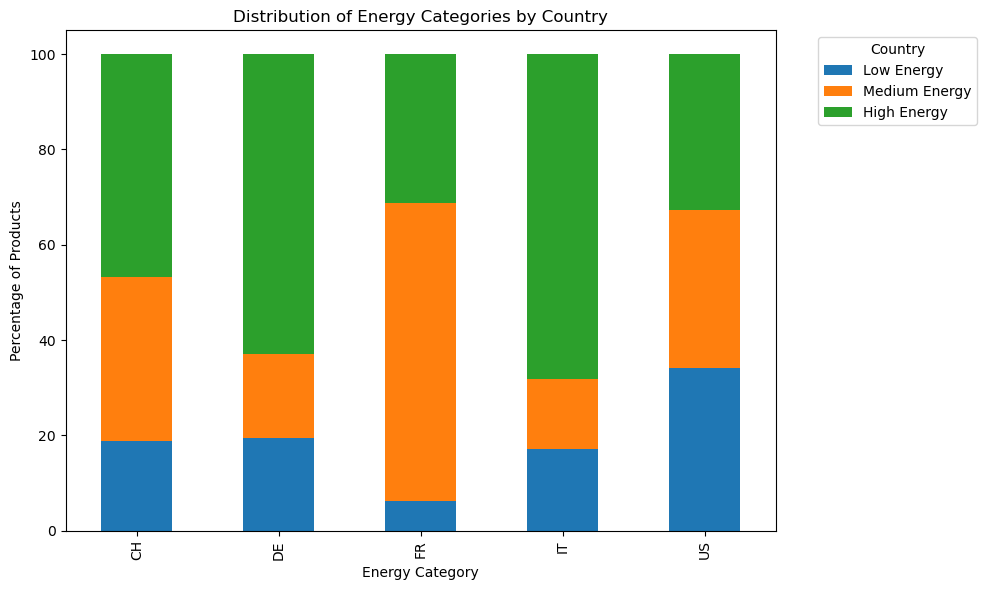

In [95]:
precetnage_table.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Distribution of Energy Categories by Country')
plt.xlabel('Energy Category')
plt.ylabel('Percentage of Products')  
plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')  
plt.tight_layout()
plt.show()


Observation:
As we can see distribution of energy category in each country. US has more percentage for low energy while France has almost zero at low energy category

## TASK G. Advanced EDA

a) Calculatig total number of samples by country.

In [96]:
product_sample = df_reset.groupby("country").count()
product_sample

,alcohol_by_volume,barcode,calcium_per_hundred,calcium_unit,carbohydrates_per_hundred,carbohydrates_unit,cholesterol_per_hundred,cholesterol_unit,created_at,energy_kcal_per_hundred,...,factor,calculated_energy,energy_difference,cleaned_ingredients,ingredient_count,created_at_datetime,hour,month,year_month,energy_category
country,,,,,,,,,,,,,,,,,,,,,
CH,7178,7178,7178,7178,7178,7178,7178,7178,7178,7178,...,7169,7178,7178,7178,7178,7178,7178,7178,7178,7178
DE,516,516,516,516,516,516,516,516,516,516,...,516,516,516,516,516,516,516,516,516,516
FR,16,16,16,16,16,16,16,16,16,16,...,16,16,16,16,16,16,16,16,16,16
IT,135,135,135,135,135,135,135,135,135,135,...,135,135,135,135,135,135,135,135,135,135
US,186322,186322,186322,186322,186322,186322,186322,186322,186322,186322,...,174767,186322,186322,186322,186322,186322,186322,186322,186322,186322


Countries with very small sample size should be dropped from this analysis as their results may not be statistically significant.

In [97]:
Country_small_size = ['AT', 'FR', 'UK' ]
for country in Country_small_size:
    df_reset = df_reset.drop(df_reset[df_reset['country'] == country ].index)

In [98]:
product_sample = df_reset.groupby("country").count()
product_sample

,alcohol_by_volume,barcode,calcium_per_hundred,calcium_unit,carbohydrates_per_hundred,carbohydrates_unit,cholesterol_per_hundred,cholesterol_unit,created_at,energy_kcal_per_hundred,...,factor,calculated_energy,energy_difference,cleaned_ingredients,ingredient_count,created_at_datetime,hour,month,year_month,energy_category
country,,,,,,,,,,,,,,,,,,,,,
CH,7178,7178,7178,7178,7178,7178,7178,7178,7178,7178,...,7169,7178,7178,7178,7178,7178,7178,7178,7178,7178
DE,516,516,516,516,516,516,516,516,516,516,...,516,516,516,516,516,516,516,516,516,516
IT,135,135,135,135,135,135,135,135,135,135,...,135,135,135,135,135,135,135,135,135,135
US,186322,186322,186322,186322,186322,186322,186322,186322,186322,186322,...,174767,186322,186322,186322,186322,186322,186322,186322,186322,186322


**b)Counting the number of organic and non-organic products in each country ad finding country with a higher percentage of organic products**

In [99]:
#Creating df as new dataframe 
df = df_reset.copy()
df = df.dropna(subset=["product_name_en"])

In [100]:
df_product_country_list = df[['product_name_en', 'country']]
food_varity_list = []
df['product_name_en']

for text in df['product_name_en']:
    text = text.lower()
    text_list = text.split()
    if 'organic' in text_list:   
        food_varity_list.append('organic')
    elif 'bio' in text_list: 
       food_varity_list.append('organic')
    else:
       food_varity_list.append('non_organic')


df['food_varity'] = food_varity_list
    

In [101]:
df_new = df.groupby(['country', 'food_varity']).size()
df_new = df_new.reset_index()
df_pivot = df_new.pivot(index="country", columns="food_varity")
df_pivot

0        
food_varity non_organic organic
country                        
CH                 6680     387
DE                  491      21
IT                  116       4
US               178236    8086

In [102]:
df_pivot = df_pivot.reset_index()
df_pivot.columns = ['country' , 'non_organic' ,'organic']
df_pivot

,country,non_organic,organic
0,CH,6680,387
1,DE,491,21
2,IT,116,4
3,US,178236,8086


In [103]:
df_pivot['organic_percentage'] = df_pivot['organic'] / (df_pivot['organic'] + df_pivot['non_organic']) * 100
df_pivot

,country,non_organic,organic,organic_percentage
0,CH,6680,387,5.476157
1,DE,491,21,4.101562
2,IT,116,4,3.333333
3,US,178236,8086,4.339799


Observation : Germany is the country with highest percentage of organic product.

**c)Comparing the distributions of the macronutrients between organic and non-organic products in each country.**

To effectively compare the distributions of macronutrients between organic and non-organic products in each country, focusing on the distribution (rather than just totals or portions) will give us a much deeper and more insightful understanding of the data. 

In [104]:
macronutrient_columns_value = df_reset[['fat_per_hundred', 'protein_per_hundred', 'carbohydrates_per_hundred']]
macronutrient_columns_value

,fat_per_hundred,protein_per_hundred,carbohydrates_per_hundred
0,0.42,11.0,75.0
1,18.00,19.0,1.5
2,21.00,19.5,11.1
3,29.50,5.6,60.5
4,1.50,13.0,70.0
...,...,...,...
194162,16.00,3.6,2.8
194163,6.70,1.1,55.0
194164,37.00,10.0,48.0
194165,0.00,0.0,11.0


In [105]:
df_f = df.groupby(['country', 'food_varity']).agg({'protein_per_hundred': 'mean', 'fat_per_hundred': 'mean', 'carbohydrates_per_hundred': 'mean'})

In [106]:
df_f = df_f.reset_index()
df_f

,country,food_varity,protein_per_hundred,fat_per_hundred,carbohydrates_per_hundred
0,CH,non_organic,7.629662,14.384420,29.036967
1,CH,organic,7.256982,10.907829,25.517209
2,DE,non_organic,6.485033,14.907739,39.463707
3,DE,organic,7.147619,9.900000,46.466667
4,IT,non_organic,8.759224,14.700000,36.111207
5,IT,organic,7.200000,1.525000,8.475000
6,US,non_organic,6.049093,8.435470,24.044841
7,US,organic,3.883889,5.110594,17.863636


In [107]:
macronutrient_columns = ['fat_per_hundred', 'protein_per_hundred', 'carbohydrates_per_hundred']

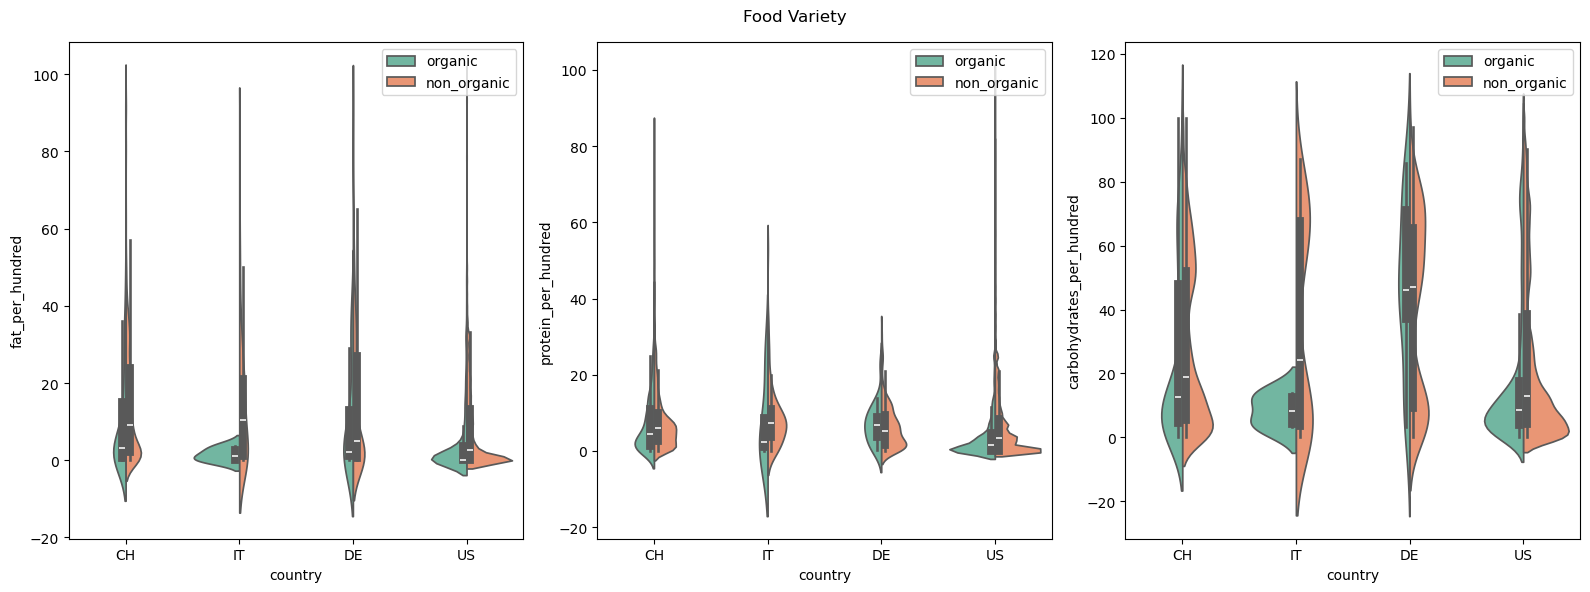

In [108]:
fig, axes = plt.subplots(ncols=3, nrows=1, figsize=(16, 6))

for col, ax in zip(macronutrient_columns, axes.ravel()):
    sns.violinplot(
        data=df,
        x=df['country'],
        y=df[col],
        ax=ax,
        palette="Set2",
        split=True,
        hue="food_varity",
    )
    ax.legend(loc='upper right')
fig.suptitle('Food Variety')
plt.tight_layout()

Observations:
As we can predict from graph that distriution of organic and non organic food varity different in every country.
Even macronutrients distribution also different.
Some countries might have very narrow or very wide distributions, showing how consistent or variable the macronutrient content is in each country's organic and non-organic products.
In carohydrates_per_hundred, there is nearlly symmeretical distriution in food varity such as organic and non-organic in every country.